# Space-Time modelling of taxes effects on pollution, and pollution effects on health outcomes in the EU countries

### Prerequisites - install libraries

In [ ]:
install.packages(c("readxl", "sp", "plm", "splm", "spdep", "texreg", "spatialreg","spData", "lmtest", "googledrive", "tidyverse",
                  #  "fda.usc",
                   "tseries"))
# library(fda.usc)
library(sp)
library(plm)
library(splm)
library(spdep) #useful to turn a W matrix into a list w matrix
library(texreg)
library(spatialreg)
library(spData)
library(lmtest)
library(readxl)
library(googledrive)
library(tidyverse)
library(dplyr)
library(tseries)
library(ggplot2)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘miscTools’, ‘rbibutils’, ‘dotCall64’, ‘classInt’, ‘wk’, ‘proxy’, ‘TH.data’, ‘checkmate’, ‘insight’, ‘xts’, ‘TTR’, ‘bdsmatrix’, ‘collapse’, ‘zoo’, ‘sandwich’, ‘maxLik’, ‘Rdpack’, ‘Formula’, ‘spam’, ‘sf’, ‘deldir’, ‘units’, ‘s2’, ‘e1071’, ‘coda’, ‘mvtnorm’, ‘LearnBayes’, ‘multcomp’, ‘marginaleffects’, ‘quadprog’, ‘quantmod’


Loading required package: spData

To access larger datasets in this package, install the spDataLarge
package with: `install.packages('spDataLarge',
repos='https://nowosad.github.io/drat/', type='source')`

Loading required package: sf

Linking to GEOS 3.12.1, GDAL 3.8.4, PROJ 9.3.1; sf_use_s2() is TRUE

Version:  1.39.5
Date:     2025-12-21
Author:   Philip Leifeld (University of Manchester)

Consider submitting praise using the praise or praise_interactive functions.
Please cite the JSS article in your publications -- see citation("texreg").

Loadin

### Data load

In [ ]:
# Specify the path to your XLSX file
file_path <- "Environmental taxes indicators.xlsx"

# Get all sheet names from the XLSX file
sheet_names <- excel_sheets(file_path)

# Create an empty list to store data frames from each sheet
environmental_taxes_data <- list()

# Loop through each sheet name and read the data into the list
# Skip 8 rows to start reading from row 9, and use row 9 as column names
for (sheet in sheet_names) {
  cat(paste("Reading sheet:", sheet, "\n"))
  environmental_taxes_data[[sheet]] <- read_excel(file_path, sheet = sheet, skip = 8, col_names = TRUE)
  print(head(environmental_taxes_data[[sheet]]))
  cat("\n")
}

Reading sheet: Total env tax %gdp 
# A tibble: 6 × 18
  TIME     `2008` `2009` `2010` `2011` `2012` `2013` `2014` `2015` `2016` `2017`
  <chr>     <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>
1 Europea…   2.4    2.5    2.47   2.55   2.6    2.68   2.72   2.68   2.7    2.65
2 Belgium    2.3    2.35   2.43   2.53   2.48   2.49   2.51   2.55   2.68   2.7 
3 Bulgaria   3.28   2.84   2.75   2.67   2.65   2.86   2.84   2.95   2.98   2.8 
4 Czechia    2.25   2.3    2.24   2.31   2.2    2.09   2.11   2.04   2.08   1.98
5 Denmark    4.15   3.98   4.01   4.01   3.97   4.12   4.01   3.98   3.93   3.67
6 Germany    2.48   2.66   2.44   2.63   2.59   2.73   2.74   2.62   2.58   2.56
# ℹ 7 more variables: `2018` <dbl>, `2019` <dbl>, `2020` <dbl>, `2021` <dbl>,
#   `2022` <dbl>, `2023` <dbl>, `2024` <dbl>

Reading sheet: Energy taxes %gdp 
# A tibble: 6 × 18
  TIME     `2008` `2009` `2010` `2011` `2012` `2013` `2014` `2015` `2016` `2017`
  <chr>     <dbl>  <dbl>  <dbl>  <dbl>  

In [ ]:
file_path <- "Pollution indicators.xlsx"
sheet_names <- excel_sheets(file_path)
pollution_indicators_data <- list()
for (sheet in sheet_names) {
  cat(paste("Reading sheet:", sheet, "\n"))
  pollution_indicators_data[[sheet]] <- read_excel(file_path, sheet = sheet, skip = 8, col_names = TRUE)
  print(head(pollution_indicators_data[[sheet]]))
  cat("\n")
}

Reading sheet: 1. Greenhouse kgcapita 
# A tibble: 6 × 18
  TIME     `2008` `2009` `2010` `2011` `2012` `2013` `2014` `2015` `2016` `2017`
  <chr>     <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>
1 Europe… 8.61 e6 7.86e6 8.01e6 7.89e6 7.72e6 7.49e6 7.29e6 7.36e6 7.32e6 7.42e6
2 Belgium 1.03 e7 9.24e6 9.74e6 8.98e6 8.58e6 8.35e6 8.13e6 8.34e6 8.27e6 8.23e6
3 Bulgar… 8.35 e6 7.26e6 7.65e6 8.41e6 7.79e6 7.22e6 7.80e6 8.34e6 8.10e6 8.49e6
4 Czechia 1.19 e7 1.09e7 1.11e7 1.08e7 1.03e7 9.94e6 9.84e6 9.67e6 9.89e6 9.69e6
5 Denmark 1.86 e7 1.74e7 1.71e7 1.69e7 1.56e7 1.52e7 1.42e7 1.47e7 1.55e7 1.53e7
6 Germany 1.000e7 9.26e6 9.59e6 9.62e6 9.73e6 9.81e6 9.49e6 9.46e6 9.27e6 9.12e6
# ℹ 7 more variables: `2018` <dbl>, `2019` <dbl>, `2020` <dbl>, `2021` <dbl>,
#   `2022` <dbl>, `2023` <dbl>, `2024` <dbl>

Reading sheet: 2. Acidifying gases kgcapita 
# A tibble: 6 × 17
  TIME     `2008` `2009` `2010` `2011` `2012` `2013` `2014` `2015` `2016` `2017`
  <chr>     <dbl>  <dbl> 

In [ ]:
file_path <- "Health indicators.xlsx"
sheet_names <- excel_sheets(file_path)
health_indicators_data <- list()
for (sheet in sheet_names) {
  cat(paste("Reading sheet:", sheet, "\n"))
  # Read data, skipping 8 rows to use row 9 as column names
  temp_df <- read_excel(file_path, sheet = sheet, skip = 8, col_names = TRUE)
  # Remove the first row of the temporary data frame (which is original row 10)
  health_indicators_data[[sheet]] <- temp_df[-1, ]
  print(head(health_indicators_data[[sheet]]))
  cat("\n")
}

Reading sheet: 1. Death - respiratory 
# A tibble: 6 × 17
  TIME     `2008` `2009` `2010` `2011` `2012` `2013` `2014` `2015` `2016` `2017`
  <chr>     <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>
1 Europea…   78.6   79.3   73.7   42.2   42.5   75.5   71.0   81.0   74.9   79.7
2 Belgium   119.   114.   107.   106.   112.   109.    95.7  109.   101.   108. 
3 Bulgaria   69.7   62.2   61.4   61.5   62     54.0   58.3   60.4   65.0   67.3
4 Czechia    75.5   81.5   76.4   72.9   72.9   82.0   73.4   86.6   80.5   89.6
5 Denmark   127.   134.   131.   128.   125.   128.   116.   118.   117.   122. 
6 Germany    74.9   78.2   72.8   74.4   73.5   77.2   68.0   77.3   71.2   74.6
# ℹ 6 more variables: `2018` <dbl>, `2019` <dbl>, `2020` <dbl>, `2021` <dbl>,
#   `2022` <dbl>, `2023` <dbl>

Reading sheet: 2. Life expectancy 
# A tibble: 6 × 18
  TIME     `2008` `2009` `2010` `2011` `2012` `2013` `2014` `2015` `2016` `2017`
  <chr>     <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <d

In [ ]:
file_path <- "Control variables.xlsx"
sheet_names <- excel_sheets(file_path)
control_variables_data <- list()
for (sheet in sheet_names) {
  cat(paste("Reading sheet:", sheet, "\n"))
  # Read data, skipping 8 rows to use row 9 as column names
  temp_df <- read_excel(file_path, sheet = sheet, skip = 8, col_names = TRUE)
  # Remove the first row of the temporary data frame (which is original row 10)
  control_variables_data[[sheet]] <- temp_df[-1, ]
  print(head(control_variables_data[[sheet]]))
  cat("\n")
}

Reading sheet: 1. Health expenditcap 
# A tibble: 6 × 17
  TIME     `2008` `2009` `2010` `2011` `2012` `2013` `2014` `2015` `2016` `2017`
  <chr>    <chr>  <chr>  <chr>  <chr>  <chr>  <chr>   <dbl>  <dbl>  <dbl>  <dbl>
1 Europea… :      :      :      :      :      :       2668.  2748.  2819.  2915.
2 Belgium  3153.… 3396.0 3471.… 3572.… 3697.… 3761.…  3837.  4012.  4121.  4265.
3 Bulgaria :      :      :      400.95 436.05 419.48   467.   485.   528.   578.
4 Czechia  :      :      1138.… 1185.… 1174.7 1136.…  1139.  1179.  1242.  1345.
5 Denmark  :      :      4649.… 4630.… 4790.… 4759.8  4855.  4969.  5067.  5164.
6 Germany  3163.… 3341.… 3464.… 3601.… 3688.… 3819.…  3969.  4126.  4258.  4454.
# ℹ 6 more variables: `2018` <dbl>, `2019` <dbl>, `2020` <dbl>, `2021` <dbl>,
#   `2022` <dbl>, `2023` <dbl>

Reading sheet: Health exp %GDP 
# A tibble: 6 × 17
  TIME     `2008` `2009` `2010` `2011` `2012` `2013` `2014` `2015` `2016` `2017`
  <chr>    <chr>  <chr>  <chr>  <chr>  <chr>  <chr>  

In [ ]:
# Specify the path to your XLSX file
file_path <- "Environmental taxes indicators_per_pers.xlsx"

# Get all sheet names from the XLSX file
sheet_names <- excel_sheets(file_path)

# Create an empty list to store data frames from each sheet
environmental_taxes_per_pers_data <- list()

# Loop through each sheet name and read the data into the list
# Skip 8 rows to start reading from row 9, and use row 9 as column names
for (sheet in sheet_names) {
  cat(paste("Reading sheet:", sheet, "\n"))
  environmental_taxes_per_pers_data[[sheet]] <- read_excel(file_path, sheet = sheet, skip = 8, col_names = TRUE)
  print(head(environmental_taxes_per_pers_data[[sheet]]))
  cat("\n")
}

Reading sheet: total mil euro 
# A tibble: 6 × 31
  TIME     `1995` `1996` `1997` `1998` `1999` `2000` `2001` `2002` `2003` `2004`
  <chr>     <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>
1 Europea… 1.64e5 1.75e5 1.78e5 1.86e5 1.99e5 2.03e5 2.12e5 2.21e5 2.31e5 2.41e5
2 Belgium  5.30e3 5.85e3 5.95e3 5.99e3 6.28e3 6.17e3 6.32e3 6.40e3 6.80e3 7.52e3
3 Bulgaria 1.75e2 8.00e1 1.16e2 3.14e2 3.15e2 4.02e2 3.95e2 4.13e2 5.27e2 6.33e2
4 Czechia  1.21e3 1.30e3 1.25e3 1.30e3 1.43e3 1.51e3 1.76e3 1.98e3 2.07e3 2.34e3
5 Denmark  6.10e3 6.71e3 6.99e3 8.32e3 8.82e3 8.60e3 8.87e3 9.49e3 9.29e3 1.01e4
6 Germany  4.21e4 4.23e4 4.15e4 4.18e4 4.63e4 5.10e4 5.62e4 5.72e4 6.12e4 6.08e4
# ℹ 20 more variables: `2005` <dbl>, `2006` <dbl>, `2007` <dbl>, `2008` <dbl>,
#   `2009` <dbl>, `2010` <dbl>, `2011` <dbl>, `2012` <dbl>, `2013` <dbl>,
#   `2014` <dbl>, `2015` <dbl>, `2016` <dbl>, `2017` <dbl>, `2018` <dbl>,
#   `2019` <dbl>, `2020` <dbl>, `2021` <dbl>, `2022` <dbl>, `2023` <dbl>,
#

In [ ]:
# Process a list of data frames: pivot to long format and add metadata
process_data_list <- function(data_list, indicator_type) {
  processed_dfs <- list()
  for (sheet_name in names(data_list)) {
    df <- data_list[[sheet_name]]

    df <- df %>% rename(Country = TIME)

    # Convert all columns except 'Country' to numeric, coercing errors to NA
    # Also, remove any '...' columns that might be generated by read_excel for empty headers
    df <- df %>%
      select(-starts_with("...")) %>%
      mutate(across(where(is.character) & !matches("Country"), ~as.numeric(str_replace_all(., ",", "")))) %>%
      mutate(across(where(is.numeric) & !matches("Country"), as.numeric))

    # Get all year columns (numeric column names)
    year_cols <- names(df)[!names(df) %in% c("Country")]

    # Pivot longer and add metadata
    long_df <- df %>%
      pivot_longer(cols = all_of(year_cols), names_to = "Year", values_to = "Value", values_drop_na = FALSE) %>%
      mutate(Year = as.numeric(gsub("X", "", Year))) %>% # Convert Year to numeric, remove 'X' if present
      mutate(Indicator_Name = sheet_name, Indicator_Type = indicator_type)

    processed_dfs[[sheet_name]] <- long_df
  }
  bind_rows(processed_dfs)
}

# Process each category of data
environmental_taxes_long <- process_data_list(environmental_taxes_data, "Environmental Taxes")
pollution_indicators_long <- process_data_list(pollution_indicators_data, "Pollution Indicators")
health_indicators_long <- process_data_list(health_indicators_data, "Health Indicators")
control_variables_long <- process_data_list(control_variables_data, "Control Variables")
environmental_taxes_per_pers_long <- process_data_list(environmental_taxes_per_pers_data, "Environmental Taxes Per Capita")

# Combine all processed data into a single master dataframe
master_df <- bind_rows(
  environmental_taxes_long,
  environmental_taxes_per_pers_long,
  pollution_indicators_long,
  health_indicators_long,
  control_variables_long
)

# Display the first few rows of the master dataframe and its structure
cat("\nFirst few rows of the master dataframe:\n")
print(head(master_df))

cat("\nStructure of the master dataframe:\n")
print(str(master_df))

Warning message:
“There were 6 warnings in `mutate()`.
The first warning was:
ℹ In argument: `across(...)`.
Caused by warning:
! NAs introduced by coercion
ℹ Run `dplyr::last_dplyr_warnings()` to see the 5 remaining warnings.”
Warning message:
“There were 6 warnings in `mutate()`.
The first warning was:
ℹ In argument: `across(...)`.
Caused by warning:
! NAs introduced by coercion
ℹ Run `dplyr::last_dplyr_warnings()` to see the 5 remaining warnings.”



First few rows of the master dataframe:
# A tibble: 6 × 5
  Country                               Year Value Indicator_Name Indicator_Type
  <chr>                                <dbl> <dbl> <chr>          <chr>         
1 European Union - 27 countries (from…  2008  2.4  Total env tax… Environmental…
2 European Union - 27 countries (from…  2009  2.5  Total env tax… Environmental…
3 European Union - 27 countries (from…  2010  2.47 Total env tax… Environmental…
4 European Union - 27 countries (from…  2011  2.55 Total env tax… Environmental…
5 European Union - 27 countries (from…  2012  2.6  Total env tax… Environmental…
6 European Union - 27 countries (from…  2013  2.68 Total env tax… Environmental…

Structure of the master dataframe:
tibble [15,092 × 5] (S3: tbl_df/tbl/data.frame)
 $ Country       : chr [1:15092] "European Union - 27 countries (from 2020)" "European Union - 27 countries (from 2020)" "European Union - 27 countries (from 2020)" "European Union - 27 countries (from 2020)" 

### Creating a Weighted Pollution Index

1.  Normalizing the given weights so they sum to 100%.
2.  Extracting the relevant pollution indicator data.
3.  Calculating the weighted average for each country and year.

In [ ]:
# Define the given weighting factors and map them to Indicator_Name in the dataframe

weights_df = data.frame(
  Indicator_Name = c("1. Greenhouse kgcapita", "4. P2.5 kg capita", "2. Acidifying gases kgcapita", "3. Ozone kgcapita"),
  Given_Weight_Percent = c(21.06, 8.96, 6.20, 4.78)
)

# Updated cleaning function to handle "1. Name" and "1 Name"
clean_indicator_names <- function(name_vec) {
  # Removes leading numbers followed by either a period and space OR just a space
  # Modified regex: ^[0-9]+(\\.\\s*|\\s+)
  name_vec <- str_replace(name_vec, "^[0-9]+(\\.\\s*|\\s+)", "")
  return(name_vec)
}

# Apply renaming to the weights dataframe
weights_df$Indicator_Name <- clean_indicator_names(weights_df$Indicator_Name)

# Apply renaming to the master_df
master_df <- master_df %>%
  mutate(Indicator_Name = clean_indicator_names(Indicator_Name))

# Normalize the weights to sum to 100%
sum_given_weights <- sum(weights_df$Given_Weight_Percent)
weights_df$Normalized_Weight <- (weights_df$Given_Weight_Percent / sum_given_weights) * 100

cat("Normalized Weights (with cleaned names):\n")
print(weights_df)

# Prepare data for weighted sum calculation
weighted_factors <- setNames(weights_df$Normalized_Weight / 100, weights_df$Indicator_Name)

# Filter and pivot wide the relevant pollution indicators
relevant_pollution_indicators_df <- master_df %>%
  filter(Indicator_Type == "Pollution Indicators" & Indicator_Name %in% names(weighted_factors)) %>%
  pivot_wider(
    id_cols = c(Country, Year),
    names_from = Indicator_Name,
    values_from = Value
  )

# Calculate the Pollution Index
relevant_pollution_indicators_df$Pollution_Index <- 0

for (indicator in names(weighted_factors)) {
  col_name <- indicator
  weight <- weighted_factors[[indicator]]

  if (col_name %in% colnames(relevant_pollution_indicators_df)) {
    relevant_pollution_indicators_df[[col_name]][is.na(relevant_pollution_indicators_df[[col_name]])] <- 0
    relevant_pollution_indicators_df$Pollution_Index <- relevant_pollution_indicators_df$Pollution_Index +
                                                      (relevant_pollution_indicators_df[[col_name]] * weight)
  } else {
    warning(paste("Indicator column not found:", col_name))
  }
}

# Prepare the calculated Pollution Index to be added as new rows
pollution_index_rows <- relevant_pollution_indicators_df %>%
  select(Country, Year, Value = Pollution_Index) %>%
  mutate(
    Indicator_Name = "Pollution Index",
    Indicator_Type = "Pollution Indicators"
  )

cat("\nFirst few rows of the calculated Pollution Index:\n")
print(head(pollution_index_rows))

# Bind the new Pollution Index rows to the master_df
# Note: We filter out existing 'Pollution Index' to avoid duplicates during re-runs
master_df <- master_df %>%
  filter(Indicator_Name != "Pollution Index") %>%
  bind_rows(pollution_index_rows)

cat("\nUnique Indicator Names after improved cleaning:\n")
print(unique(master_df$Indicator_Name))

Normalized Weights (with cleaned names):
             Indicator_Name Given_Weight_Percent Normalized_Weight
1       Greenhouse kgcapita                21.06          51.36585
2            P2.5 kg capita                 8.96          21.85366
3 Acidifying gases kgcapita                 6.20          15.12195
4            Ozone kgcapita                 4.78          11.65854

First few rows of the calculated Pollution Index:
# A tibble: 6 × 5
  Country                              Year  Value Indicator_Name Indicator_Type
  <chr>                               <dbl>  <dbl> <chr>          <chr>         
1 European Union - 27 countries (fro…  2008 4.44e6 Pollution Ind… Pollution Ind…
2 European Union - 27 countries (fro…  2009 4.05e6 Pollution Ind… Pollution Ind…
3 European Union - 27 countries (fro…  2010 4.13e6 Pollution Ind… Pollution Ind…
4 European Union - 27 countries (fro…  2011 4.07e6 Pollution Ind… Pollution Ind…
5 European Union - 27 countries (fro…  2012 3.98e6 Pollution Ind… Pol

In [ ]:
write.csv(master_df, "master_data.csv", row.names = FALSE)

### Summary statistics

In [ ]:
cat("\nSummary statistics for specific indicators (excluding EU aggregated values, 2008-2024):\n")

# Define the specific list of variables with more descriptive names
indicator_name_map <- c(
  "energy tax euro pers" = "Energy Tax per Person (Euro)",
  "transport tax euro pers" = "Transport Tax per Person (Euro)",
  "pol tax euro pers" = "Pollution Tax per Person (Euro)",
  "Acidifying gases kgcapita" = "Acidifying Gases (kg/capita)",
  "Ozone kgcapita" = "Ozone (kg/capita)",
  "Greenhouse kgcapita" = "Greenhouse Gases (kg/capita)",
  "P2.5 kg capita" = "Particulate Matter (P2.5 kg/capita)",
  "Pollution Index" = "Pollution Index",
  "Death - respiratory" = "Death - Respiratory Diseases",
  "Death-cardiovascular diseases" = "Death - Cardiovascular Diseases",
  "Life expectancy" = "Life Expectancy",
  "Health expenditcap" = "Health Expenditure per Capita",
  "Health exp %GDP" = "Health Expenditure (% GDP)",
  "Energy cons-cap" = "Energy Consumption per Capita",
  "Real GDP-cap" = "Real GDP per Capita"
)

# Filter out 'European Union' rows from the Country column
# Filter by the specified Indicator_Name list and Year range
filtered_df <- master_df %>%
  filter(
    !str_detect(Country, "European Union"),
    Indicator_Name %in% names(indicator_name_map),
    Year >= 2008 & Year <= 2024
  )

# Group by Indicator_Name and summarize key statistics including year ranges
grouped_summary_stats <- filtered_df %>%
  group_by(Indicator_Name) %>%
  summarise(
    Year_From = min(Year, na.rm = TRUE),
    Year_To = max(Year, na.rm = TRUE),
    Min = min(Value, na.rm = TRUE),
    Max = max(Value, na.rm = TRUE),
    Mean = mean(Value, na.rm = TRUE),
    Median = median(Value, na.rm = TRUE),
    SD = sd(Value, na.rm = TRUE),
    NA_Count = sum(is.na(Value)),
    Count = n()
  ) %>%
  # Apply the descriptive names for display
  mutate(Indicator_Name = dplyr::recode(Indicator_Name, !!!indicator_name_map))

# Display the results in a formatted table
# Check if knitr is installed, if not, install it
if (!requireNamespace("knitr", quietly = TRUE)) {
  install.packages("knitr")
}
library(knitr)

kable(grouped_summary_stats, caption = "Summary Statistics by Indicator (with Year Range)", digits = 4)


Summary statistics for specific indicators (excluding EU aggregated values, 2008-2024):




Table: Summary Statistics by Indicator (with Year Range)

|Indicator_Name                      | Year_From| Year_To|          Min|          Max|         Mean|       Median|           SD| NA_Count| Count|
|:-----------------------------------|---------:|-------:|------------:|------------:|------------:|------------:|------------:|--------:|-----:|
|Acidifying Gases (kg/capita)        |      2008|    2023|   14702.3394| 3.405180e+05|   45643.3372|   33510.6611|   47338.7652|        0|   432|
|Death - Respiratory Diseases        |      2008|    2023|      27.7200| 1.581300e+02|      77.7698|      76.1950|      26.6330|        0|   432|
|Death - Cardiovascular Diseases     |      2008|    2023|     163.2600| 1.210960e+03|     486.8848|     386.5000|     250.9049|        0|   432|
|Energy Consumption per Capita       |      2008|    2023|   66591.4400| 3.974363e+05|  152427.4517|  133458.0150|   59892.1298|        0|   432|
|Greenhouse Gases (kg/capita)        |      2008|    2024| 38884

* 459 values: Many indicators (e.g., '1. Greenhouse kgcapita', 'Energy taxes %gdp') have data spanning from 2008 to 2024, covering 17 years. Since we're looking at 27 EU countries (excluding the aggregated EU row), 27 countries * 17 years = 459 observations.  
* 432 values: Other indicators (e.g., '1. Death - respiratory', 'Health expenditcap', 'Health exp %GDP', '3. Real GDP-cap') only have data available up to 2023. This means they cover 16 years (2008-2023), resulting in 27 countries * 16 years = 432 observations.  
* 189 values: As you noted, '4. Smoking prevalence' has even fewer values because its data is available for a more limited and non-continuous set of years (2006, 2009, 2012, 2014, 2017, 2020, 2023), totaling 7 years. So, 27 countries * 7 years = 189 observations.

In [ ]:
# Dynamically define all variables to be normalized from the master_df
variables_to_normalize <- unique(master_df$Indicator_Name)

cat("Normalizing", length(variables_to_normalize), "unique indicators.\n")

# Filter master_df for these indicators (effectively all rows)
df_filtered <- master_df %>%
  filter(Indicator_Name %in% variables_to_normalize)

# Separate data for individual countries and EU aggregated values
df_countries <- df_filtered %>%
  filter(!str_detect(Country, "European Union"))

df_eu <- df_filtered %>%
  filter(str_detect(Country, "European Union"))

# Apply min-max normalization to individual countries per indicator
normalized_countries <- df_countries %>%
  group_by(Indicator_Name) %>%
  mutate(Normalized_Value = (Value - min(Value, na.rm = TRUE)) / (max(Value, na.rm = TRUE) - min(Value, na.rm = TRUE))) %>%
  ungroup() %>%
  dplyr::select(Country, Year, Indicator_Name, Normalized_Value)

# Apply min-max normalization to EU aggregated values per indicator
normalized_eu <- df_eu %>%
  group_by(Indicator_Name) %>%
  mutate(Normalized_Value = (Value - min(Value, na.rm = TRUE)) / (max(Value, na.rm = TRUE) - min(Value, na.rm = TRUE))) %>%
  ungroup() %>%
  dplyr::select(Country, Year, Indicator_Name, Normalized_Value)

# Combine the normalized data
combined_normalized_data <- bind_rows(normalized_countries, normalized_eu)

# Clean master_df of any existing 'Normalized_Value' column before joining to avoid duplicates
if ("Normalized_Value" %in% colnames(master_df)) {
  master_df <- master_df %>% dplyr::select(-Normalized_Value)
}

# Join the normalized values back to the master_df
master_df <- master_df %>%
  left_join(combined_normalized_data, by = c("Country", "Year", "Indicator_Name"))

# Verification
cat("\nSummary of normalized values (0 to 1 check):\n")
summary(master_df$Normalized_Value)

cat("\nFirst few rows of updated master_df:\n")
print(head(master_df %>% filter(!is.na(Normalized_Value))))

Normalizing 27 unique indicators.

Summary of normalized values (0 to 1 check):


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
0.00000 0.04617 0.14688 0.24136 0.37213 1.00000     120 


First few rows of updated master_df:
# A tibble: 6 × 6
  Country              Year Value Indicator_Name Indicator_Type Normalized_Value
  <chr>               <dbl> <dbl> <chr>          <chr>                     <dbl>
1 European Union - 2…  2008  2.4  Total env tax… Environmental…            0.515
2 European Union - 2…  2009  2.5  Total env tax… Environmental…            0.667
3 European Union - 2…  2010  2.47 Total env tax… Environmental…            0.621
4 European Union - 2…  2011  2.55 Total env tax… Environmental…            0.742
5 European Union - 2…  2012  2.6  Total env tax… Environmental…            0.818
6 European Union - 2…  2013  2.68 Total env tax… Environmental…            0.939


We've performed normalization for each indicator by calculating the min and max values across all years and all individual countries. It then does a separate normalization for the EU aggregated values using their own min and max for each indicator.

This means that a Normalized_Value of 0.5 for a country might not be directly comparable to a Normalized_Value of 0.5 for the EU aggregate, because they were scaled using different min/max ranges.

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




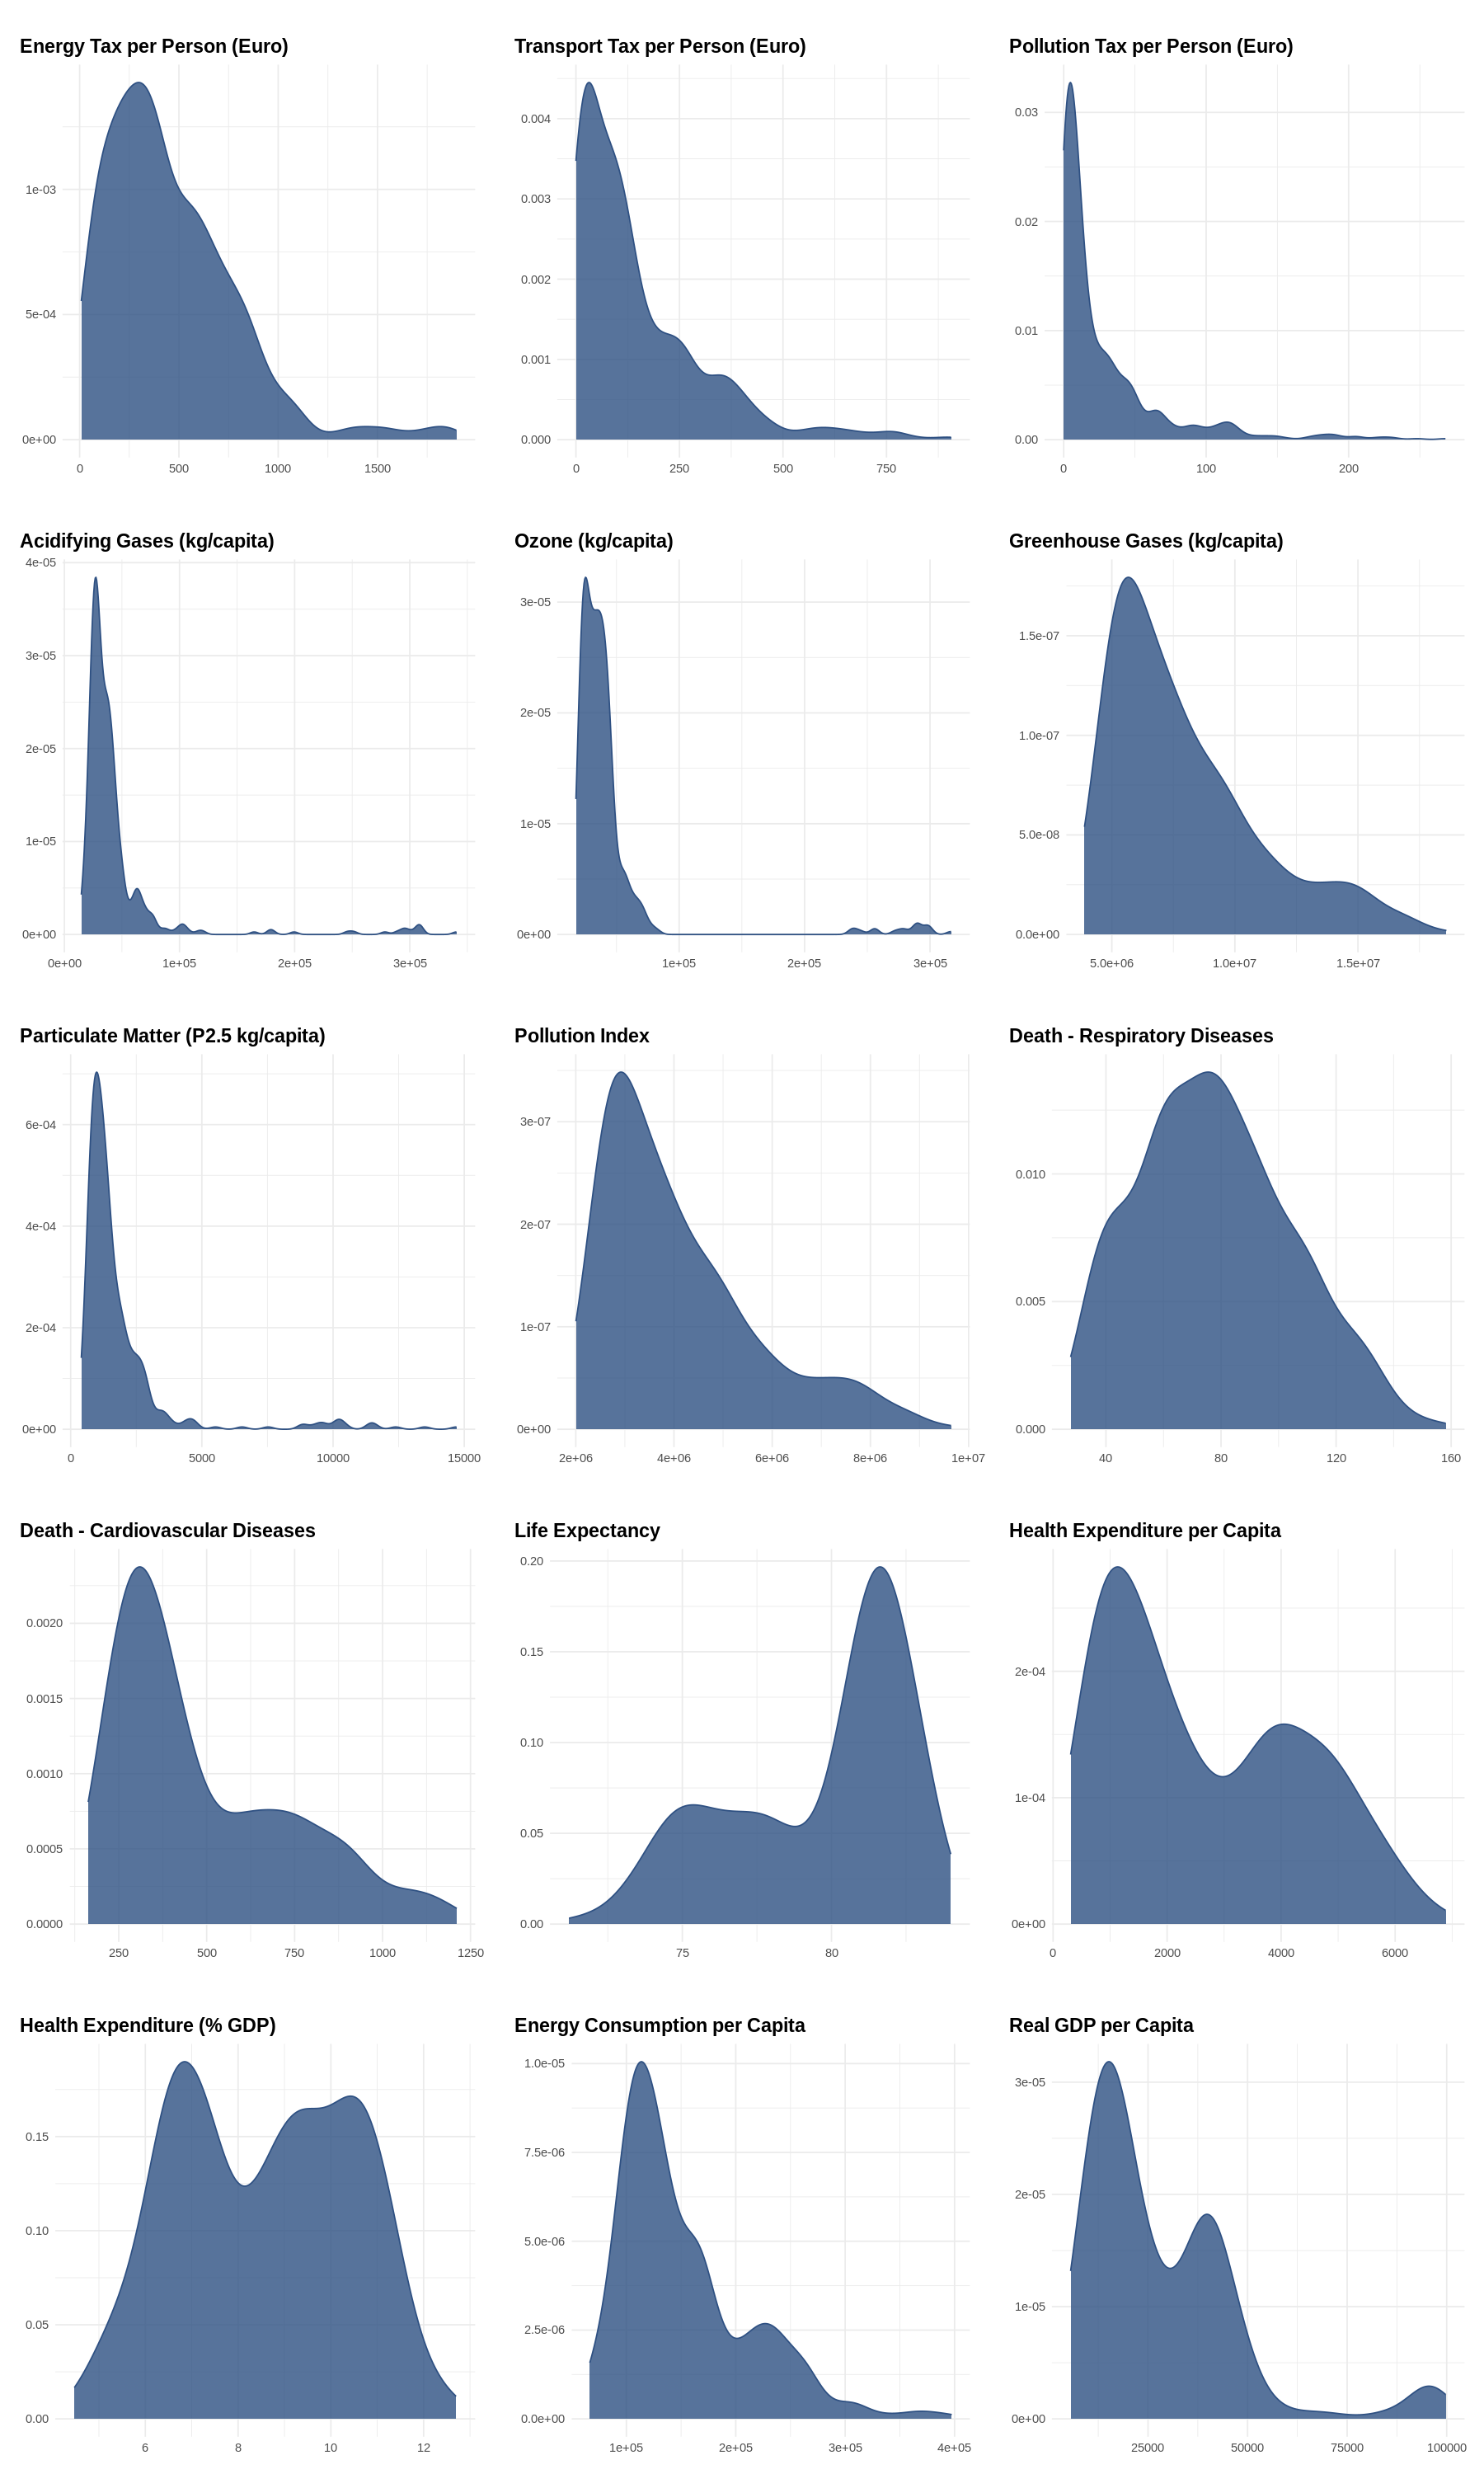

In [ ]:
options(repr.plot.width = 15, repr.plot.height = 25)

# Define the specific list of variables with more descriptive names
indicators <- c(
  "Energy Tax per Person (Euro)",
  "Transport Tax per Person (Euro)",
  "Pollution Tax per Person (Euro)",
  "Acidifying Gases (kg/capita)",
  "Ozone (kg/capita)",
  "Greenhouse Gases (kg/capita)",
  "Particulate Matter (P2.5 kg/capita)",
  "Pollution Index",
  "Death - Respiratory Diseases",
  "Death - Cardiovascular Diseases",
  "Life Expectancy",
  "Health Expenditure per Capita",
  "Health Expenditure (% GDP)",
  "Energy Consumption per Capita",
  "Real GDP per Capita"
)

# Map original indicator names to new display names
indicator_name_map <- c(
  "energy tax euro pers" = "Energy Tax per Person (Euro)",
  "transport tax euro pers" = "Transport Tax per Person (Euro)",
  "pol tax euro pers" = "Pollution Tax per Person (Euro)",
  "Acidifying gases kgcapita" = "Acidifying Gases (kg/capita)",
  "Ozone kgcapita" = "Ozone (kg/capita)",
  "Greenhouse kgcapita" = "Greenhouse Gases (kg/capita)",
  "P2.5 kg capita" = "Particulate Matter (P2.5 kg/capita)",
  "Pollution Index" = "Pollution Index",
  "Death - respiratory" = "Death - Respiratory Diseases",
  "Death-cardiovascular diseases" = "Death - Cardiovascular Diseases",
  "Life expectancy" = "Life Expectancy",
  "Health expenditcap" = "Health Expenditure per Capita",
  "Health exp %GDP" = "Health Expenditure (% GDP)",
  "Energy cons-cap" = "Energy Consumption per Capita",
  "Real GDP-cap" = "Real GDP per Capita"
)

# Filter master_df for relevant data and indicators, using original names for filtering
plot_df_dist <- master_df %>%
  filter(!str_detect(Country, "European Union")) %>%
  filter(Indicator_Name %in% names(indicator_name_map))

# Replace original Indicator_Name with new display names in the filtered dataframe
plot_df_dist <- plot_df_dist %>%
  mutate(Indicator_Name = dplyr::recode(Indicator_Name, !!!indicator_name_map))

# Create a list to store plots
plot_list_dist <- list()

# Loop through each requested indicator to create a density plot
for (indicator_display_name in indicators) {
  # Filter for the specific indicator using its new display name
  data_for_plot <- plot_df_dist %>%
    filter(Indicator_Name == indicator_display_name, !is.na(Value))

  if (nrow(data_for_plot) > 0) {
    p <- ggplot(data_for_plot, aes(x = Value)) +
      geom_density(fill = "#2e5082", color = "#2e5082", alpha = 0.8) + # Changed fill color to a magma palette color
      labs(title = indicator_display_name) + # Using labs for direct title assignment
      theme_minimal() +
      theme(
        plot.title = element_text(size = 14, face = "bold", color = "black", vjust = 1), # Align top of title with top of title area
        axis.title = element_blank(), # Removed axis titles
        plot.title.position = "plot", # Ensure title is positioned at the plot area
        plot.margin = unit(c(1, 0.5, 0.5, 0.5), "cm") # Increased top margin
      )
    plot_list_dist[[indicator_display_name]] <- p
  } else {
    cat(paste("No non-NA data found for:", indicator_display_name, "\n"))
  }
}

# Arrange and print the plots in a grid
if (!requireNamespace("gridExtra", quietly = TRUE)) install.packages("gridExtra")
library(gridExtra)

if (length(plot_list_dist) > 0) {
  grid.arrange(grobs = plot_list_dist, ncol = 3)
} else {
  cat("No indicators found to plot.")
}

# Reset plot dimensions
options(repr.plot.width = 7, repr.plot.height = 7)

In [ ]:
master_df <- master_df %>%
  group_by(Country, Indicator_Name) %>%
  arrange(Country, Year) %>% # Ensure data is ordered correctly for lag function
  mutate(Log_Return_Value = log(Value / lag(Value))) %>%
  ungroup()

cat("First few rows of master_df with the new Log_Return_Value column (where applicable):\n")
print(head(master_df))

cat("\nStructure of master_df after adding Log_Return_Value column:\n")
print(str(master_df))

First few rows of master_df with the new Log_Return_Value column (where applicable):
# A tibble: 6 × 7
  Country  Year     Value Indicator_Name         Indicator_Type Normalized_Value
  <chr>   <dbl>     <dbl> <chr>                  <chr>                     <dbl>
1 Austria  1995    3979.  total mil euro         Environmental…          0.0461 
2 Austria  1995    2592.  energy tax mil euro    Environmental…          0.0343 
3 Austria  1995    1357.  transport tax mil euro Environmental…          0.115  
4 Austria  1995      30.3 pol tax mil euro       Environmental…          0.00630
5 Austria  1995 7943489   POPULATION             Environmental…          0.0911 
6 Austria  1995     501.  total tax euro pers    Environmental…          0.242  
# ℹ 1 more variable: Log_Return_Value <dbl>

Structure of master_df after adding Log_Return_Value column:
tibble [15,568 × 7] (S3: tbl_df/tbl/data.frame)
 $ Country         : chr [1:15568] "Austria" "Austria" "Austria" "Austria" ...
 $ Year         

In [ ]:
colSums(is.na(master_df))

Country             Year            Value   Indicator_Name 
               0                0              120                0 
  Indicator_Type Normalized_Value Log_Return_Value 
               0              120             1070

### Time series for the pollution index

In [ ]:
# Filter out 2006 data, 'European Union' aggregate, and specifically select 'Pollution Index' rows
filtered_pollution_df <- master_df %>%
  filter(
    Year != 2006, # Exclude 2006 due to missing values
    !str_detect(Country, "European Union"), # Exclude aggregated EU data
    Indicator_Name == "Pollution Index" # Select only the calculated Pollution Index
  ) %>%
  # We need Country, Year, and the Value (which is the Pollution_Index) for further use
  dplyr::select(Country, Year, Pollution_Index = Value) %>% # Rename Value to Pollution_Index for clarity in this filtered df
  drop_na(Pollution_Index) # Drop any remaining NAs in Pollution_Index if any

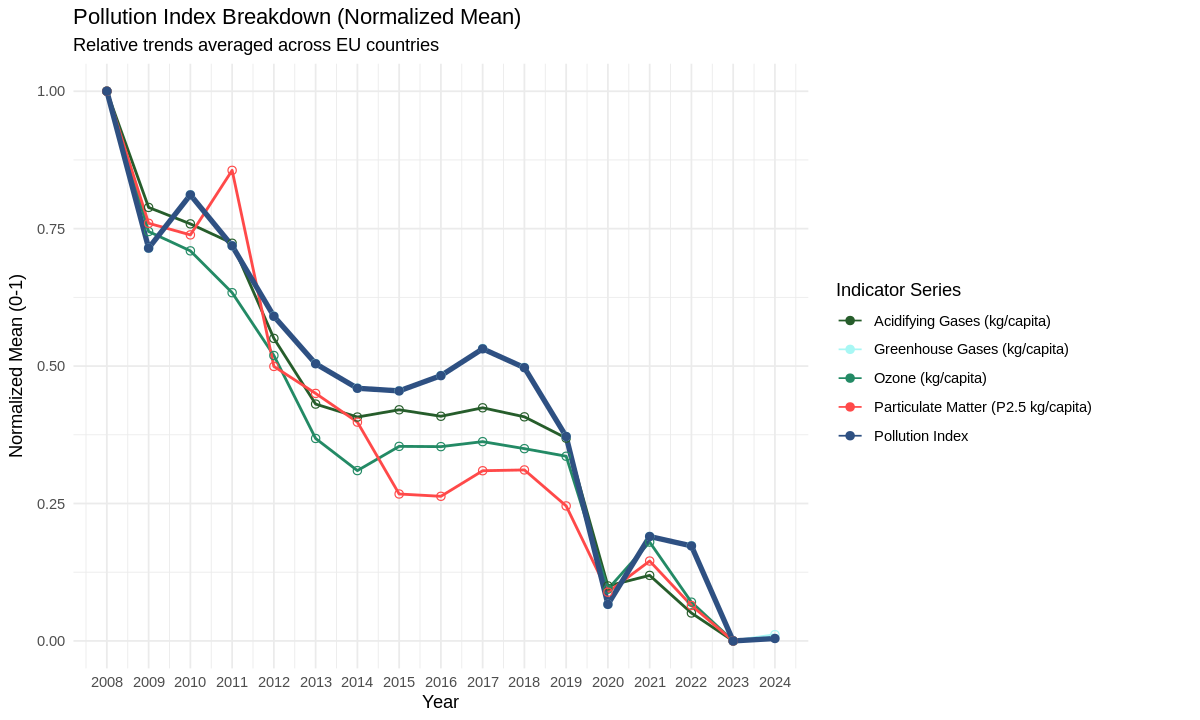

In [ ]:
indicator_names_for_index <- c("Greenhouse kgcapita", "P2.5 kg capita", "Acidifying gases kgcapita", "Ozone kgcapita")

# --- Component trends (from individual countries) ---
component_pollution_trends <- master_df %>%
  filter(
    Indicator_Type == "Pollution Indicators",
    Indicator_Name %in% indicator_names_for_index,
    Year != 2006,
    !str_detect(Country, "European Union")
  ) %>%
  drop_na(Value) %>%
  group_by(Year, Indicator_Name) %>%
  summarise(Mean_Value = mean(Value, na.rm = TRUE), .groups = 'drop') %>%
  mutate(Series_Name = Indicator_Name)

# --- Overall Index as MEAN of individual countries ---
# Using the Pollution Index calculated in earlier steps
overall_pollution_trend <- master_df %>%
  filter(
    Indicator_Name == "Pollution Index",
    Year != 2006,
    !str_detect(Country, "European Union")
  ) %>%
  group_by(Year) %>%
  summarise(Mean_Value = mean(Value, na.rm = TRUE), .groups = 'drop') %>%
  mutate(Series_Name = "Pollution Index")

# Combine and normalize for visualization (0-1 scale for comparison)
combined_trends <- bind_rows(component_pollution_trends, overall_pollution_trend) %>%
  group_by(Series_Name) %>%
  mutate(Normalized_Mean = (Mean_Value - min(Mean_Value, na.rm = TRUE)) / (max(Mean_Value, na.rm = TRUE) - min(Mean_Value, na.rm = TRUE))) %>%
  ungroup() %>%
  mutate(Series_Type = ifelse(Series_Name == "Pollution Index", "Pollution Index", "Component Indicator"))

# Define the name map for plot legends
indicator_name_map <- c(
  "Acidifying gases kgcapita" = "Acidifying Gases (kg/capita)",
  "Ozone kgcapita" = "Ozone (kg/capita)",
  "Greenhouse kgcapita" = "Greenhouse Gases (kg/capita)",
  "P2.5 kg capita" = "Particulate Matter (P2.5 kg/capita)",
  "Pollution Index" = "Pollution Index"
)

# Recode Series_Name using the map for legend display
combined_trends <- combined_trends %>%
  mutate(Series_Name = dplyr::recode(Series_Name, !!!indicator_name_map))

# Define custom colors and linewidths for the plot with updated names
colors_manual <- c(
  "Pollution Index" = "#2e5082",
  "Greenhouse Gases (kg/capita)" = "#a8f7f4",
  "Particulate Matter (P2.5 kg/capita)" = "#ff4949",
  "Acidifying Gases (kg/capita)" = "#265d2b",
  "Ozone (kg/capita)" = "#238a65"
)

linewidths_manual <- c("Pollution Index" = 1.5, "Component Indicator" = 0.8)

# Set plot dimensions
options(repr.plot.width = 10, repr.plot.height = 6)

ggplot(combined_trends, aes(x = Year, y = Normalized_Mean, color = Series_Name, linewidth = Series_Type)) +
  geom_line() +
  geom_point(aes(shape = Series_Type), size = 2) +
  scale_color_manual(values = colors_manual) +
  scale_linewidth_manual(values = linewidths_manual) +
  scale_shape_manual(values = c("Pollution Index" = 19, "Component Indicator" = 1)) +
  labs(
    title = "Pollution Index Breakdown (Normalized Mean)",
    subtitle = "Relative trends averaged across EU countries",
    x = "Year",
    y = "Normalized Mean (0-1)",
    color = "Indicator Series" # This will now show the new names
  ) +
  theme_minimal() +
  guides(linewidth = "none", shape = "none") +
  scale_x_continuous(breaks = unique(combined_trends$Year))

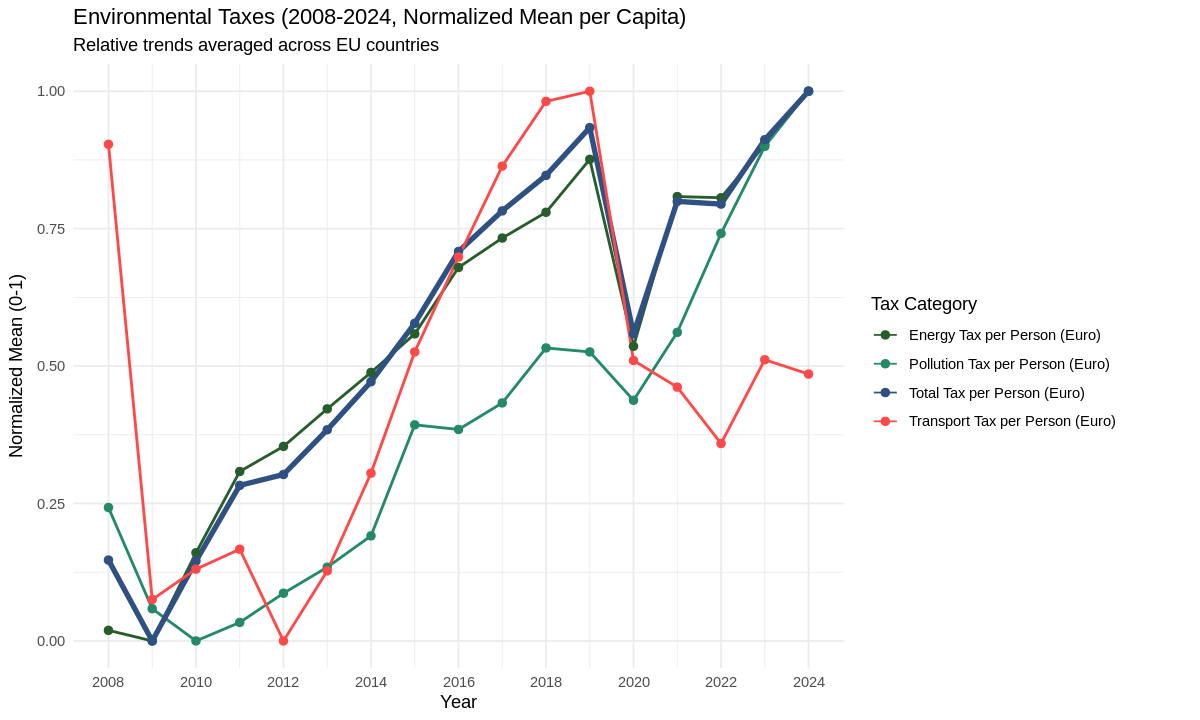

In [ ]:
# Define the names of the tax indicators to visualize
tax_indicators <- c(
  "total tax euro pers",
  "transport tax euro pers",
  "energy tax euro pers",
  "pol tax euro pers"
)

# --- Calculate trends for tax indicators (mean across individual countries) ---
# Filtered for the requested range 2008-2024
tax_trends <- master_df %>%
  filter(
    Indicator_Name %in% tax_indicators,
    !str_detect(Country, "European Union"),
    Year >= 2008 & Year <= 2024
  ) %>%
  drop_na(Value) %>%
  group_by(Year, Indicator_Name) %>%
  summarise(Mean_Value = mean(Value, na.rm = TRUE), .groups = 'drop')

# Normalize for visualization (0-1 scale for comparison)
combined_tax_trends <- tax_trends %>%
  group_by(Indicator_Name) %>%
  mutate(Normalized_Mean = (Mean_Value - min(Mean_Value, na.rm = TRUE)) / (max(Mean_Value, na.rm = TRUE) - min(Mean_Value, na.rm = TRUE))) %>%
  ungroup() %>%
  mutate(Line_Type = ifelse(Indicator_Name == "total tax euro pers", "Total Tax", "Other Tax"))

# Define the name map for plot legends
indicator_name_map <- c(
  "energy tax euro pers" = "Energy Tax per Person (Euro)",
  "transport tax euro pers" = "Transport Tax per Person (Euro)",
  "pol tax euro pers" = "Pollution Tax per Person (Euro)",
  "total tax euro pers" = "Total Tax per Person (Euro)"
)

# Recode Indicator_Name using the map for legend display
combined_tax_trends <- combined_tax_trends %>%
  mutate(Indicator_Name = dplyr::recode(Indicator_Name, !!!indicator_name_map))

# Define custom colors for the plot
colors_manual_taxes <- c(
  "Total Tax per Person (Euro)" = "#2e5082",
  "Transport Tax per Person (Euro)" = "#ff4949",
  "Energy Tax per Person (Euro)" = "#265d2b",
  "Pollution Tax per Person (Euro)" = "#238a65"
)

# Define custom linewidths for the plot
linewidths_manual_taxes <- c("Total Tax" = 1.5, "Other Tax" = 0.8)

# Set plot dimensions
options(repr.plot.width = 10, repr.plot.height = 6)

ggplot(combined_tax_trends, aes(x = Year, y = Normalized_Mean, color = Indicator_Name, linewidth = Line_Type)) +
  geom_line() +
  geom_point(size = 2) +
  scale_color_manual(values = colors_manual_taxes) +
  scale_linewidth_manual(values = linewidths_manual_taxes) +
  labs(
    title = "Environmental Taxes (2008-2024, Normalized Mean per Capita)",
    subtitle = "Relative trends averaged across EU countries",
    x = "Year",
    y = "Normalized Mean (0-1)",
    color = "Tax Category"
  ) +
  theme_minimal() +
  guides(linewidth = "none") +
  scale_x_continuous(breaks = seq(2008, 2024, 2))

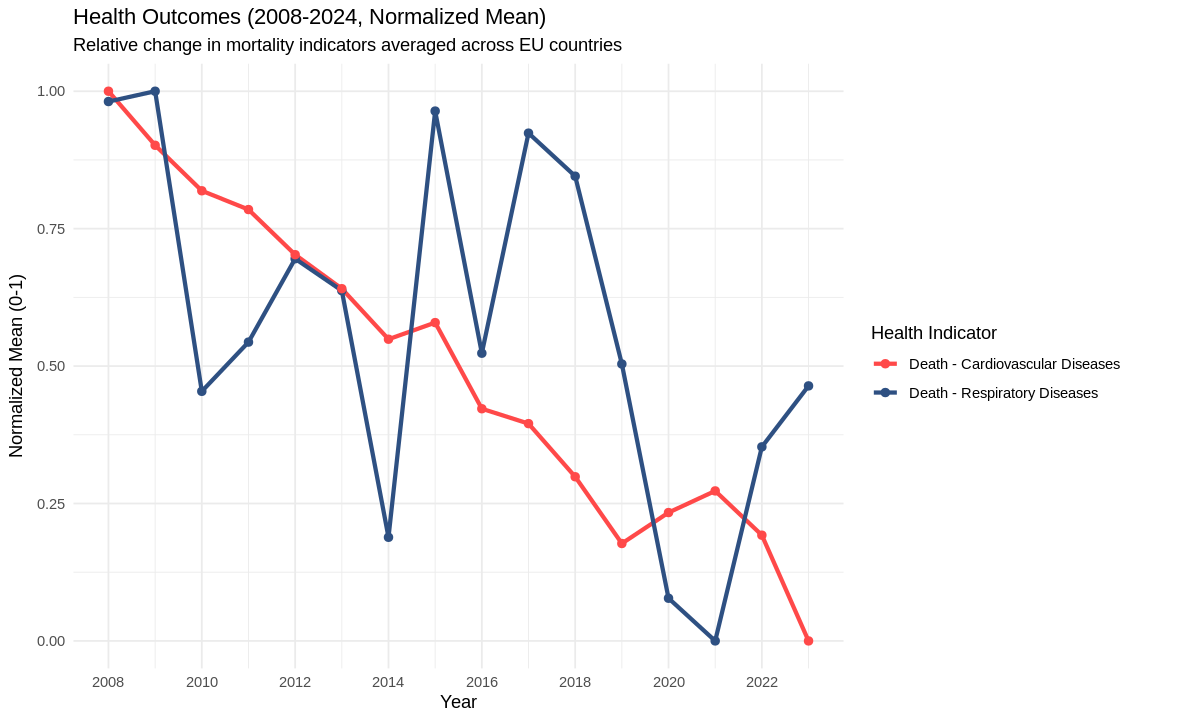

In [ ]:
# Define the names of the health indicators to visualize
health_indicators <- c(
  "Death-cardiovascular diseases",
  "Death - respiratory"
)

# --- Calculate trends for health indicators (mean across individual countries) ---
# Filtered for the requested range 2008-2024
health_trends <- master_df %>%
  filter(
    Indicator_Name %in% health_indicators,
    !str_detect(Country, "European Union"),
    Year >= 2008 & Year <= 2024
  ) %>%
  drop_na(Value) %>%
  group_by(Year, Indicator_Name) %>%
  summarise(Mean_Value = mean(Value, na.rm = TRUE), .groups = 'drop')

# Normalize for visualization (0-1 scale for comparison)
combined_health_trends <- health_trends %>%
  group_by(Indicator_Name) %>%
  mutate(Normalized_Mean = (Mean_Value - min(Mean_Value, na.rm = TRUE)) / (max(Mean_Value, na.rm = TRUE) - min(Mean_Value, na.rm = TRUE))) %>%
  ungroup()

# Define the name map for plot legends specific to health indicators
indicator_name_map_health <- c(
  "Death - respiratory" = "Death - Respiratory Diseases",
  "Death-cardiovascular diseases" = "Death - Cardiovascular Diseases"
)

# Recode Indicator_Name using the map for legend display
combined_health_trends <- combined_health_trends %>%
  mutate(Indicator_Name = dplyr::recode(Indicator_Name, !!!indicator_name_map_health))

# Define custom colors for the health plot with updated names
colors_manual_health <- c(
  "Death - Cardiovascular Diseases" = "#ff4949",
  "Death - Respiratory Diseases" = "#2e5082"
)

# Set plot dimensions
options(repr.plot.width = 10, repr.plot.height = 6)

ggplot(combined_health_trends, aes(x = Year, y = Normalized_Mean, color = Indicator_Name)) +
  geom_line(linewidth = 1.2) +
  geom_point(size = 2) +
  scale_color_manual(values = colors_manual_health) +
  labs(
    title = "Health Outcomes (2008-2024, Normalized Mean)",
    subtitle = "Relative change in mortality indicators averaged across EU countries",
    x = "Year",
    y = "Normalized Mean (0-1)",
    color = "Health Indicator"
  ) +
  theme_minimal() +
  scale_x_continuous(breaks = seq(2008, 2024, 2))

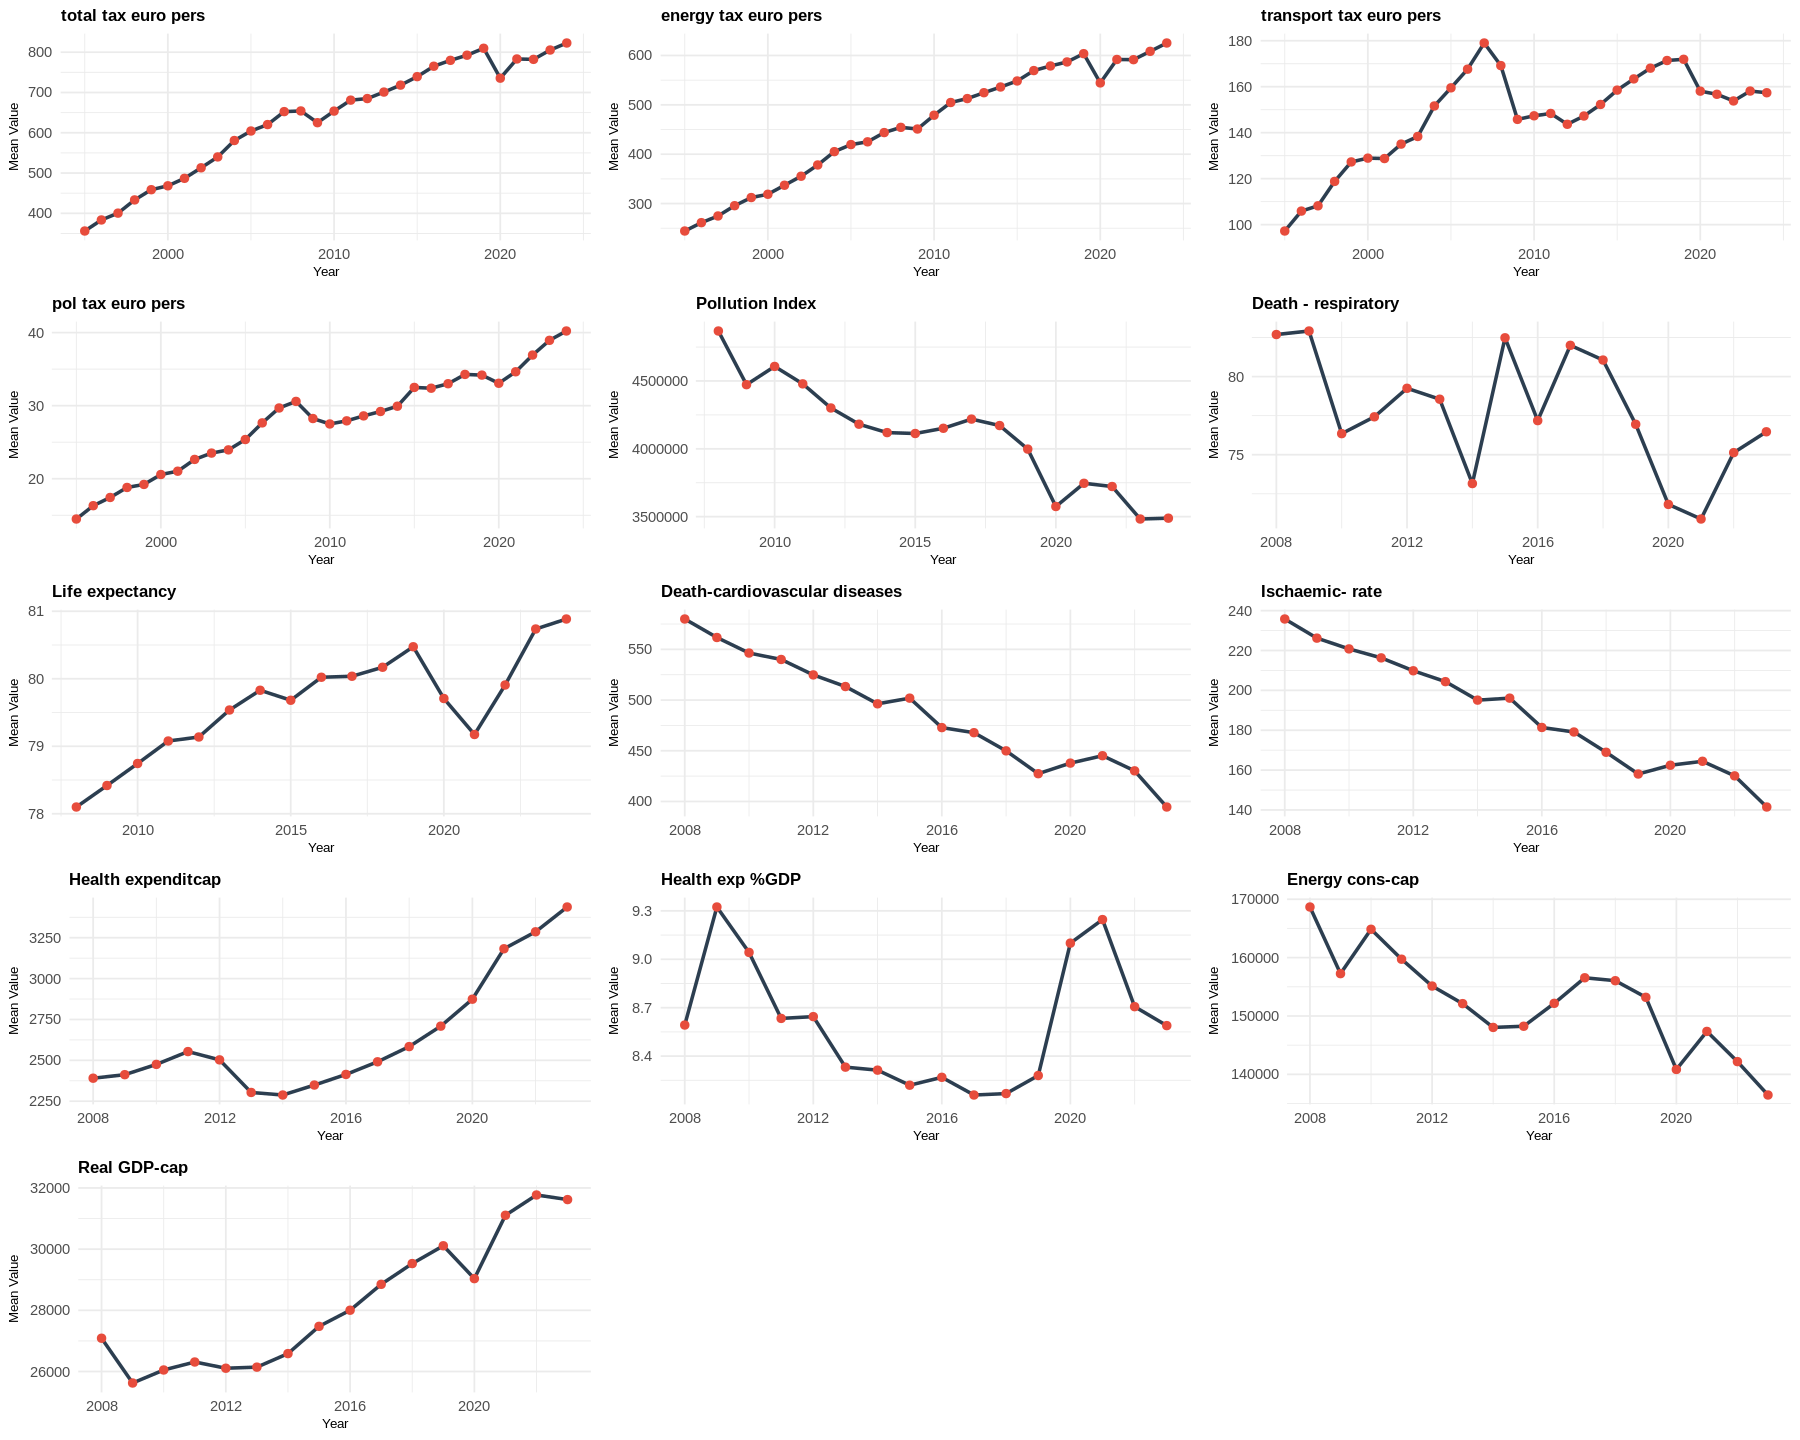

In [ ]:
options(repr.plot.width = 15, repr.plot.height = 12)

# Define variables to plot
time_series_indicators <- c(
  "total tax euro pers",
  "energy tax euro pers",
  "transport tax euro pers",
  "pol tax euro pers",
  "Pollution Index",
  "Death - respiratory",
  "Life expectancy",
  "Death-cardiovascular diseases",
  "Ischaemic- rate",
  "Health expenditcap",
  "Health exp %GDP",
  "Energy cons-cap",
  "Real GDP-cap"
)

# Calculate the mean value per year for each indicator across countries
trend_data <- master_df %>%
  filter(!str_detect(Country, "European Union")) %>%
  filter(Indicator_Name %in% time_series_indicators) %>%
  group_by(Year, Indicator_Name) %>%
  summarise(Mean_Value = mean(Value, na.rm = TRUE), .groups = 'drop')

plot_list_trends <- list()

for (indicator in time_series_indicators) {
  data_subset <- trend_data %>% filter(Indicator_Name == indicator)

  if (nrow(data_subset) > 0) {
    p <- ggplot(data_subset, aes(x = Year, y = Mean_Value)) +
      geom_line(color = "#2c3e50", linewidth = 1) +
      geom_point(color = "#e74c3c", size = 2) +
      labs(
        title = indicator,
        x = "Year",
        y = "Mean Value"
      ) +
      theme_minimal() +
      theme(
        plot.title = element_text(size = 10, face = "bold"),
        axis.title = element_text(size = 8)
      )
    plot_list_trends[[indicator]] <- p
  }
}

# Display in a grid
if (length(plot_list_trends) > 0) {
  grid.arrange(grobs = plot_list_trends, ncol = 3)
} else {
  cat("No data found for the requested time series.")
}

# Reset options
options(repr.plot.width = 7, repr.plot.height = 7)

In [ ]:
# 1. Impute zeros and create log-transformed versions for ALL indicators in master_df
# Step 1a: Replace 0 with a very small value (1e-6) to retain observations in log-models
# Step 1b: Perform log transformation
master_df <- master_df %>%
  mutate(Value_Imputed = ifelse(Value == 0, 1e-6, Value)) %>%
  mutate(Value_Log = ifelse(Value_Imputed > 0, log(Value_Imputed), NA))

# 2. Normalize these log values using min-max scaling
# We normalize for individual countries and EU aggregated values separately

# Filter for country data
log_norm_countries <- master_df %>%
  filter(!str_detect(Country, "European Union")) %>%
  group_by(Indicator_Name) %>%
  mutate(Normalized_Value_Log = (Value_Log - min(Value_Log, na.rm = TRUE)) /
                                (max(Value_Log, na.rm = TRUE) - min(Value_Log, na.rm = TRUE))) %>%
  ungroup() %>%
  select(Country, Year, Indicator_Name, Normalized_Value_Log)

# Filter for EU data
log_norm_eu <- master_df %>%
  filter(str_detect(Country, "European Union")) %>%
  group_by(Indicator_Name) %>%
  mutate(Normalized_Value_Log = (Value_Log - min(Value_Log, na.rm = TRUE)) /
                                (max(Value_Log, na.rm = TRUE) - min(Value_Log, na.rm = TRUE))) %>%
  ungroup() %>%
  select(Country, Year, Indicator_Name, Normalized_Value_Log)

# Combine the normalized log datasets
combined_log_normalized <- bind_rows(log_norm_countries, log_norm_eu)

# Clean master_df of any existing Normalized_Value_Log column before joining
if ("Normalized_Value_Log" %in% colnames(master_df)) {
  master_df <- master_df %>% select(-Normalized_Value_Log)
}

# Join the normalized log values back to the master_df
master_df <- master_df %>%
  left_join(combined_log_normalized, by = c("Country", "Year", "Indicator_Name"))

cat("Imputation of zeros, log-transformation, and normalization complete.\n")
cat("Summary of Normalized_Value_Log:\n")
print(summary(master_df$Normalized_Value_Log))

# Show sample of preprocessed data across different indicator types
cat("\nSample of transformed variables (Value_Imputed used for logs):\n")
print(head(master_df %>%
           filter(!is.na(Normalized_Value_Log)) %>%
           select(Country, Year, Indicator_Name, Value, Value_Imputed, Value_Log, Normalized_Value_Log)))

Imputation of zeros, log-transformation, and normalization complete.
Summary of Normalized_Value_Log:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
 0.0000  0.4107  0.6590  0.6071  0.8222  1.0000     120 

Sample of transformed variables (Value_Imputed used for logs):
# A tibble: 6 × 7
  Country  Year Indicator_Name             Value Value_Imputed Value_Log
  <chr>   <dbl> <chr>                      <dbl>         <dbl>     <dbl>
1 Austria  1995 total mil euro            3979.         3979.       8.29
2 Austria  1995 energy tax mil euro       2592.         2592.       7.86
3 Austria  1995 transport tax mil euro    1357.         1357.       7.21
4 Austria  1995 pol tax mil euro            30.3          30.3      3.41
5 Austria  1995 POPULATION             7943489       7943489       15.9 
6 Austria  1995 total tax euro pers        501.          501.       6.22
# ℹ 1 more variable: Normalized_Value_Log <dbl>


Avantaj major: Interpretarea este intuitivă. Coeficienții se citesc ca elasticități. (ex: „O creștere de 1% a taxelor de mediu duce la o scădere de 0,5% a mortalității”).Dezavantaj: Dacă variabilele tale au ordine de mărime extrem de diferite (ex: PIB-ul este de ordinul milioanelor, iar indicii de poluare sunt între 0 și 100), chiar și după logaritmare, scalele vor rămâne diferite, ceea ce poate face compararea directă a magnitudinii coeficienților dificilă.

In [ ]:
write.csv(master_df, "master_data.csv", row.names = FALSE)

## Load spatial weights matrix

Load the `.gal` files, which represents the spatial weights matrix created using GeoDa.

In [ ]:
drive_download(drive_get("cleaned_eu27_projected_w_knn3_sym.gal"), path = "cleaned_eu27_projected_w_knn3_sym.gal", overwrite = TRUE)
w_knn_3 <- read.gal("cleaned_eu27_projected_w_knn3_sym.gal")
w_knn_3 <- nb2listw(w_knn_3, style='W')

summary(w_knn_3)

✔ The input `path` resolved to exactly 1 file.

File downloaded:

• cleaned_eu27_projected_w_knn3_sym.gal <id: 1jETApcc6VmaZurR3rKnwUaDC9J_e9rKA>

Saved locally as:

• cleaned_eu27_projected_w_knn3_sym.gal



Characteristics of weights list object:
Neighbour list object:
Number of regions: 27 
Number of nonzero links: 114 
Percentage nonzero weights: 15.63786 
Average number of links: 4.222222 
Link number distribution:

3 4 5 6 
8 9 6 4 
8 least connected regions:
4 9 13 15 18 22 26 27 with 3 links
4 most connected regions:
1 11 16 19 with 6 links

Weights style: W 
Weights constants summary:
   n  nn S0       S1       S2
W 27 729 27 13.17389 109.8861

In [ ]:
drive_download(drive_get("cleaned_eu27_projected_w_knn4_sym.gal"), path = "cleaned_eu27_projected_w_knn4_sym.gal", overwrite = TRUE)

w_knn_4 <- read.gal("cleaned_eu27_projected_w_knn4_sym.gal")
w_knn_4 <- nb2listw(w_knn_4, style='W')

summary(w_knn_4)

✔ The input `path` resolved to exactly 1 file.

File downloaded:

• cleaned_eu27_projected_w_knn4_sym.gal <id: 1IRk5w4QhVeiCEN8AGdVK4-1SLoa2FTNd>

Saved locally as:

• cleaned_eu27_projected_w_knn4_sym.gal



Characteristics of weights list object:
Neighbour list object:
Number of regions: 27 
Number of nonzero links: 146 
Percentage nonzero weights: 20.02743 
Average number of links: 5.407407 
Link number distribution:

 4  5  6  7  8 
 7 10  5  2  3 
7 least connected regions:
3 6 9 13 22 26 27 with 4 links
3 most connected regions:
1 11 17 with 8 links

Weights style: W 
Weights constants summary:
   n  nn S0      S1       S2
W 27 729 27 10.2704 109.3763

In [ ]:
drive_download(drive_get("cleaned_eu27_projected_w_dist_sym.gal"), path = "cleaned_eu27_projected_w_dist_sym.gal", overwrite = TRUE)

w_dist <- read.gal("cleaned_eu27_projected_w_dist_sym.gal")
w_dist <- nb2listw(w_dist, style='W')

summary(w_dist) #corresponds to the w_dist of 1050 KM - euclidean

✔ The input `path` resolved to exactly 1 file.

File downloaded:

• cleaned_eu27_projected_w_dist_sym.gal <id: 13F4lrbB643Z7WljU10aaSxhEKbVNDN3d>

Saved locally as:

• cleaned_eu27_projected_w_dist_sym.gal



Characteristics of weights list object:
Neighbour list object:
Number of regions: 27 
Number of nonzero links: 278 
Percentage nonzero weights: 38.13443 
Average number of links: 10.2963 
Link number distribution:

 1  2  3  4  5  6  8  9 10 11 12 13 14 15 16 17 
 1  2  1  2  1  1  1  1  1  2  3  2  2  2  3  2 
1 least connected region:
22 with 1 link
2 most connected regions:
3 25 with 17 links

Weights style: W 
Weights constants summary:
   n  nn S0       S1       S2
W 27 729 27 8.196425 111.4736

In [ ]:
drive_download(drive_get("cleaned_eu27_projected_w_dist12000_sym.gal"), path = "cleaned_eu27_projected_w_dist12000_sym.gal", overwrite = TRUE)

w_dist_euclid1200 <- read.gal("cleaned_eu27_projected_w_dist12000_sym.gal")
w_dist_euclid1200 <- nb2listw(w_dist_euclid1200, style='W')

summary(w_dist_euclid1200)

✔ The input `path` resolved to exactly 1 file.

File downloaded:

• cleaned_eu27_projected_w_dist12000_sym.gal
  <id: 18d1dsRPGrjRIhXp3FYIXKKL7ffa0xOSi>

Saved locally as:

• cleaned_eu27_projected_w_dist12000_sym.gal



Characteristics of weights list object:
Neighbour list object:
Number of regions: 27 
Number of nonzero links: 306 
Percentage nonzero weights: 41.97531 
Average number of links: 11.33333 
Link number distribution:

 2  4  5  6  7 10 11 12 13 14 15 16 17 18 
 3  2  1  1  1  2  2  1  1  3  2  3  3  2 
3 least connected regions:
9 13 22 with 2 links
2 most connected regions:
21 25 with 18 links

Weights style: W 
Weights constants summary:
   n  nn S0       S1       S2
W 27 729 27 6.675947 112.1477

In [ ]:
drive_download(drive_get("cleaned_eu27_projected_w_dist14000_sym.gal"), path = "cleaned_eu27_projected_w_dist14000_sym.gal", overwrite = TRUE)

w_dist_euclid1400 <- read.gal("cleaned_eu27_projected_w_dist14000_sym.gal")
w_dist_euclid1400 <- nb2listw(w_dist_euclid1400, style='W')

summary(w_dist_euclid1400)

✔ The input `path` resolved to exactly 1 file.

File downloaded:

• cleaned_eu27_projected_w_dist14000_sym.gal
  <id: 1ug-tw-CYoQm1nxxF6KgdgCCaYCsdkVNH>

Saved locally as:

• cleaned_eu27_projected_w_dist14000_sym.gal



Characteristics of weights list object:
Neighbour list object:
Number of regions: 27 
Number of nonzero links: 366 
Percentage nonzero weights: 50.20576 
Average number of links: 13.55556 
Link number distribution:

 2  3  5  6  7  8 10 11 12 14 16 17 18 19 20 
 1  1  2  1  1  1  1  1  1  2  3  3  2  6  1 
1 least connected region:
22 with 2 links
1 most connected region:
17 with 20 links

Weights style: W 
Weights constants summary:
   n  nn S0       S1       S2
W 27 729 27 5.044224 111.6436

In [ ]:
drive_download(drive_get("cleaned_eu27_w_dist_geo1200.gal"), path = "cleaned_eu27_w_dist_geo1200.gal", overwrite = TRUE)

w_dist_geo1200 <- read.gal("cleaned_eu27_w_dist_geo1200.gal")
w_dist_geo1200 <- nb2listw(w_dist_geo1200, style='W')

summary(w_dist_geo1200) #to compare against the euclidean

✔ The input `path` resolved to exactly 1 file.

File downloaded:

• cleaned_eu27_w_dist_geo1200.gal <id: 1eLEZQovTxSsF17gd3jDmbZyvapgkbC0Y>

Saved locally as:

• cleaned_eu27_w_dist_geo1200.gal



Characteristics of weights list object:
Neighbour list object:
Number of regions: 27 
Number of nonzero links: 304 
Percentage nonzero weights: 41.70096 
Average number of links: 11.25926 
Link number distribution:

 2  4  5  7 10 11 12 13 14 15 16 17 18 
 3  2  2  1  2  2  1  1  3  2  3  4  1 
3 least connected regions:
9 13 22 with 2 links
1 most connected region:
25 with 18 links

Weights style: W 
Weights constants summary:
   n  nn S0       S1       S2
W 27 729 27 6.745221 112.0722

## Spatial modelling

### Taxes effects on pollution

In [ ]:
run_comprehensive_spatial_analysis <- function(dep_var_name, dep_indicator, indep_vars_map, w, start_yr = 2008, end_yr = 2024) {
  # 1. Data Preparation
  iv_clean <- names(indep_vars_map)
  dep_clean <- dep_var_name

  cat(sprintf("=== Analysis: %s ~ %s ===\n", dep_clean, paste(iv_clean, collapse = " + ")))

  model_ready_df <- master_df %>%
    filter(!str_detect(Country, "European Union"), Year >= start_yr, Year <= end_yr) %>%
    filter(Indicator_Name %in% c(dep_indicator, unname(indep_vars_map))) %>%
    select(Country, Year, Indicator_Name, Value_Log) %>%
    pivot_wider(names_from = Indicator_Name, values_from = Value_Log) %>%
    arrange(Year, Country) # EXPLICIT ALIGNMENT

  # Rename based on map
  for (i in seq_along(indep_vars_map)) {
    colnames(model_ready_df)[colnames(model_ready_df) == indep_vars_map[i]] <- names(indep_vars_map)[i]
  }
  colnames(model_ready_df)[colnames(model_ready_df) == dep_indicator] <- dep_clean

  # Impute NAs
  model_ready_df <- model_ready_df %>%
    mutate(across(all_of(c(iv_clean, dep_clean)), ~ ifelse(is.na(.), 0, .)))

  # 2. Manual Spatial Lag Calculation
  for(v in iv_clean) {
    lag_name <- paste0("w_", v)
    model_ready_df[[lag_name]] <- 0
    for(yr in unique(model_ready_df$Year)) {
      yr_idx <- model_ready_df$Year == yr
      model_ready_df[yr_idx, lag_name] <- as.numeric(lag.listw(w, model_ready_df[yr_idx, ][[v]]))
    }
  }

  # Align Country order to the listw region IDs if available
  w_ids <- attr(w$neighbours, "region.id")

  if (!is.null(w_ids) && all(model_ready_df$Country %in% w_ids)) {
    model_ready_df <- model_ready_df %>%
      mutate(.w_order = match(Country, w_ids)) %>%
      arrange(Year, .w_order) %>%
      select(-.w_order)
  } else {
    warning("Could not use region.id from w; falling back to arrange(Year, Country). Make sure this matches the order of w.")
    model_ready_df <- model_ready_df %>%
      arrange(Year, Country)
  }

  p_df <- pdata.frame(model_ready_df, index = c("Country", "Year"))
  p_df$lag_DepVar <- plm::lag(p_df[[dep_clean]], 1)
  p_df$lag_DepVar[is.na(p_df$lag_DepVar)] <- 0

  model_ready_df$lag_DepVar <- as.numeric(p_df$lag_DepVar)

  # --- Helper: safe formula names ---
  bt <- function(x) paste0("`", gsub("`", "``", x), "`")

  # --- Helper: make panel block-diagonal W for spatialreg ---
  make_panel_listw <- function(w, n_periods) {
    W <- spdep::listw2mat(w)

    W_big <- Matrix::bdiag(
      replicate(n_periods, W, simplify = FALSE)
    )

    style <- w$style
    if (is.null(style)) style <- "W"

    spdep::mat2listw(as.matrix(W_big), style = style, zero.policy = TRUE)
  }

  # --- Helper: LR test SDM vs SLX using spatialreg objects ---
  run_sdm_slx_lr_spatialreg <- function(df, dep, x_vars, w, dynamic = FALSE, label = "") {
    requireNamespace("spatialreg", quietly = TRUE)
    requireNamespace("spdep", quietly = TRUE)
    requireNamespace("Matrix", quietly = TRUE)

    # Check that the panel is balanced for block-diagonal W
    n_regions <- length(w$neighbours)
    years <- sort(unique(df$Year))
    n_periods <- length(years)

    if (nrow(df) != n_regions * n_periods) {
      stop(
        sprintf(
          "Panel dimensions do not match W: nrow(df) = %s, but length(w$neighbours) * periods = %s * %s = %s.",
          nrow(df), n_regions, n_periods, n_regions * n_periods
        )
      )
    }

    # Build block-diagonal panel weights: I_T %x% W_N
    w_panel <- make_panel_listw(w, n_periods)

    # Main RHS terms
    main_terms <- c(
      if (dynamic) "lag_DepVar",
      x_vars,
      "factor(Country)",
      "factor(Year)"
    )

    main_terms_str <- c(
      if (dynamic) bt("lag_DepVar"),
      bt(x_vars),
      "factor(Country)",
      "factor(Year)"
    )

    # Only spatially lag the substantive IVs, not the fixed effects
    durbin_formula <- as.formula(
      paste("~", paste(bt(x_vars), collapse = " + "))
    )

    model_formula <- as.formula(
      paste(bt(dep), "~", paste(main_terms_str, collapse = " + "))
    )

    # Restricted model: SLX, rho = 0
    slx_mod <- spatialreg::lmSLX(
      formula = model_formula,
      data = df,
      listw = w_panel,
      Durbin = durbin_formula,
      zero.policy = TRUE
    )

    # Unrestricted model: SDM, rho freely estimated
    sdm_mod <- spatialreg::lagsarlm(
      formula = model_formula,
      data = df,
      listw = w_panel,
      Durbin = durbin_formula,
      zero.policy = TRUE,
      method = "eigen"
    )

    lr <- spatialreg::LR.Sarlm(sdm_mod, slx_mod)

    cat(sprintf("\n\n=== LR Test: %s SDM vs SLX ===\n", label))
    cat("H0: rho = 0, so SDM collapses to SLX\n")
    print(lr)

    list(
      sdm_sarlm = sdm_mod,
      slx_lmSLX = slx_mod,
      lr_test = lr
    )
  }

  # Formulas
  w_iv_cols <- paste0("w_", iv_clean)
  form_base <- paste(dep_clean, "~", paste(iv_clean, collapse = " + "))
  form_slx  <- paste(dep_clean, "~", paste(c(iv_clean, w_iv_cols), collapse = " + "))
  form_dyn_base <- paste(dep_clean, "~ lag_DepVar + ", paste(iv_clean, collapse = " + "))
  form_dyn_slx  <- paste(dep_clean, "~ lag_DepVar + ", paste(c(iv_clean, w_iv_cols), collapse = " + "))

  # Helper function to run and store models
  execute_model <- function(formula_str, label, lag_val, error_val, is_plm_slx = FALSE) {
    cat(paste0("\n--- ", label, " --- \n"))
    # Force is_plm_slx to TRUE if no spatial components are requested from spml
    # This handles cases where spml would internally complain about missing spatial components
    if (lag_val == FALSE && error_val == "none") {
        is_plm_slx_effective <- TRUE
    } else {
        is_plm_slx_effective <- is_plm_slx
    }

    if (is_plm_slx_effective) {
      mod <- plm(as.formula(formula_str), data = p_df, model = 'within', effect = 'twoways')
      resids <- residuals(mod)
      n <- length(resids)
      rss <- sum(resids^2)
      k <- length(coef(mod))
      aic_val <- n * log(rss/n) + 2 * k
      bic_val <- n * log(rss/n) + log(n) * k
      rmse_val <- sqrt(mean(resids^2))
    } else {
      mod <- spml(as.formula(formula_str), data = p_df, listw = w,
                  model = 'within', effect = 'twoways', lag = lag_val, spatial.error = error_val)
      resids <- residuals(mod)
      ll_val <- if(!is.null(mod$logLik)) as.numeric(mod$logLik) else NA
      n_obs <- length(resids)
      n_params <- length(coef(mod)) + 2 # Assuming 2 for spatial parameter and sigma^2
      aic_val <- -2 * ll_val + 2 * n_params
      bic_val <- -2 * ll_val + log(n_obs) * n_params
      rmse_val <- sqrt(mean(resids^2))
    }

    print(summary(mod))
    # Ensure 'w' is used if it's an spml model, otherwise handle if Moran's I isn't applicable
    # For plm models, w$neighbours might not be suitable or required for residual Moran's I
    if (!is_plm_slx_effective && !is.null(w$neighbours)) {
        last_year_resids <- as.numeric(resids[(nrow(p_df) - length(w$neighbours) + 1):nrow(p_df)])
        moran_res <- moran.mc(last_year_resids, w, nsim=99)
        cat(sprintf("AIC: %.4f | BIC: %.4f | RMSE: %.4f | Moran's I: %.4f (p-value: %.4f)\n", aic_val, bic_val, rmse_val, moran_res$statistic, moran_res$p.value))
    } else {
        cat(sprintf("AIC: %.4f | BIC: %.4f | RMSE: %.4f | Moran's I: Not applicable for PLM SLX or missing weights\n", aic_val, bic_val, rmse_val))
    }
    return(mod)
  }

  # Run expanded suite and store models
  cat("\n--- STATIC MODELS ---\n")
  static_sar_model = execute_model(form_base,     "STATIC SAR", TRUE,  "n")
  static_sem_model = execute_model(form_base,     "STATIC SEM", FALSE, "b")
  static_slx_plm_model = execute_model(form_slx,      "STATIC SLX (PLM)", FALSE, "n", is_plm_slx = TRUE) # PLM version of SLX
  static_sdm_model = execute_model(form_slx,      "STATIC SDM", TRUE,  "n") # SPML version of SDM
  static_slx_spml_for_lr = execute_model(form_slx, "STATIC SLX (SPML for LR)", FALSE, "none", is_plm_slx = TRUE) # SPML version of SLX for LR test (lag=FALSE, error='none')

  # LR test: Static SDM vs Static SLX using spatialreg
  lr_static_sdm_vs_slx <- tryCatch(
    run_sdm_slx_lr_spatialreg(
      df = model_ready_df,
      dep = dep_clean,
      x_vars = iv_clean,
      w = w,
      dynamic = FALSE,
      label = "STATIC"
    ),
    error = function(e) {
      cat("\nCould not perform LR Test for Static SDM vs SLX:\n")
      cat(conditionMessage(e), "\n")
      NULL
    }
)

  cat("\n--- DYNAMIC MODELS ---\n")
  dyn_sar_model    = execute_model(form_dyn_base, "DYNAMIC SAR", TRUE,  "n")
  dyn_sem_model    = execute_model(form_dyn_base, "DYNAMIC SEM", FALSE, "b")
  dyn_slx_plm_model    = execute_model(form_dyn_slx,  "DYNAMIC SLX (PLM)", FALSE, "n", is_plm_slx = TRUE) # PLM version of SLX
  dyn_sdm_model    = execute_model(form_dyn_slx,  "DYNAMIC SDM", TRUE,  "n") # SPML version of SDM
  dyn_slx_spml_for_lr = execute_model(form_dyn_slx, "DYNAMIC SLX (SPML for LR)", FALSE, "none", is_plm_slx = TRUE) # SPML version of SLX for LR test (lag=FALSE, error='none')


  # LR test: Dynamic SDM vs Dynamic SLX using spatialreg
  lr_dynamic_sdm_vs_slx <- tryCatch(
    run_sdm_slx_lr_spatialreg(
      df = model_ready_df,
      dep = dep_clean,
      x_vars = iv_clean,
      w = w,
      dynamic = TRUE,
      label = "DYNAMIC"
    ),
    error = function(e) {
      cat("\nCould not perform LR Test for Dynamic SDM vs SLX:\n")
      cat(conditionMessage(e), "\n")
      NULL
    }
  )

  results <- list(
    static_sar = static_sar_model,
    static_sem = static_sem_model,
    static_slx_plm = static_slx_plm_model,
    static_sdm = static_sdm_model,
    static_slx_for_lr = static_slx_spml_for_lr,
    lr_static_sdm_vs_slx = lr_static_sdm_vs_slx,
    dyn_sar = dyn_sar_model,
    dyn_sem = dyn_sem_model,
    dyn_slx_plm = dyn_slx_plm_model,
    dyn_sdm = dyn_sdm_model,
    dyn_slx_for_lr = dyn_slx_spml_for_lr,
    lr_dynamic_sdm_vs_slx = lr_dynamic_sdm_vs_slx
  )

  return(results)
}

In [ ]:
multi_iv_map <- c(
  "energy_tax" = "energy tax euro pers",
  "transport_tax" = "transport tax euro pers",
  "pollution_tax" = "pol tax euro pers"
)

print("tax_on_pollution_w_dist_results")
tax_on_pollution_w_dist_results <- run_comprehensive_spatial_analysis("Pollution_Index", "Pollution Index", multi_iv_map, w_dist)
print("tax_on_pollution_w_dist_euclid1200_results")
tax_on_pollution_w_dist_euclid1200_results <- run_comprehensive_spatial_analysis("Pollution_Index", "Pollution Index", multi_iv_map, w_dist_euclid1200)
print("tax_on_pollution_w_dist_geo1200_results")
tax_on_pollution_w_dist_geo1200_results <- run_comprehensive_spatial_analysis("Pollution_Index", "Pollution Index", multi_iv_map, w_dist_geo1200)
print("tax_on_pollution_w_dist_euclid1400_results")
tax_on_pollution_w_dist_euclid1400_results <- run_comprehensive_spatial_analysis("Pollution_Index", "Pollution Index", multi_iv_map, w_dist_euclid1400)
print("tax_on_pollution_knn3_results")
tax_on_pollution_knn3_results <- run_comprehensive_spatial_analysis("Pollution_Index", "Pollution Index", multi_iv_map, w_knn_3)
print("tax_on_pollution_knn4_results")
tax_on_pollution_knn4_results <- run_comprehensive_spatial_analysis("Pollution_Index", "Pollution Index", multi_iv_map, w_knn_4)

[1] "tax_on_pollution_w_dist_results"
=== Analysis: Pollution_Index ~ energy_tax + transport_tax + pollution_tax ===

--- STATIC MODELS ---

--- STATIC SAR --- 
Spatial panel fixed effects lag model
 

Call:
splm::spml(formula = stats::as.formula(formula_str), data = p_df, 
    listw = w, model = "within", effect = "twoways", lag = lag_val, 
    spatial.error = error_val)

Residuals:
    Min.  1st Qu.   Median  3rd Qu.     Max. 
-0.40210 -0.04321 -0.00133  0.03938  0.76983 

Spatial autoregressive coefficient:
        Estimate Std. Error t-value Pr(>|t|)
lambda -0.032109   0.084034 -0.3821   0.7024

Coefficients:
                Estimate Std. Error t-value  Pr(>|t|)    
energy_tax    -0.0202277  0.0262936 -0.7693    0.4417    
transport_tax  0.1509996  0.0208461  7.2436 4.371e-13 ***
pollution_tax -0.0032392  0.0024702 -1.3113    0.1898    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

AIC: -908.0428 | BIC: -883.2685 | RMSE: 0.0888 | Moran's I: 0.0555 (p-value: 0.

Warning message in spdep::mat2listw(W_big, style = style, zero.policy = TRUE):
“neighbour object has 17 sub-graphs”




=== LR Test: STATIC SDM vs SLX ===
H0: rho = 0; SDM collapses to SLX.

	Likelihood ratio for spatial linear models

data:  
Likelihood ratio = 0.39001, df = 1, p-value = 0.5323
sample estimates:
Log likelihood of sdm_mod Log likelihood of slx_mod 
                 461.9416                  461.7466 


--- DYNAMIC MODELS ---

--- DYNAMIC SAR --- 
Spatial panel fixed effects lag model
 

Call:
splm::spml(formula = stats::as.formula(formula_str), data = p_df, 
    listw = w, model = "within", effect = "twoways", lag = lag_val, 
    spatial.error = error_val)

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-0.315735 -0.031937 -0.000326  0.030690  0.512344 

Spatial autoregressive coefficient:
        Estimate Std. Error t-value Pr(>|t|)
lambda -0.036158   0.073312 -0.4932   0.6219

Coefficients:
                Estimate Std. Error t-value  Pr(>|t|)    
lag_DepVar     0.4580244  0.0313256 14.6214 < 2.2e-16 ***
energy_tax    -0.0224532  0.0216869 -1.0353  0.300513    
transp

Warning message in spdep::mat2listw(W_big, style = style, zero.policy = TRUE):
“neighbour object has 17 sub-graphs”




=== LR Test: DYNAMIC SDM vs SLX ===
H0: rho = 0; SDM collapses to SLX.

	Likelihood ratio for spatial linear models

data:  
Likelihood ratio = 0.4631, df = 1, p-value = 0.4962
sample estimates:
Log likelihood of sdm_mod Log likelihood of slx_mod 
                 550.8191                  550.5875 

[1] "tax_on_pollution_w_dist_euclid1200_results"
=== Analysis: Pollution_Index ~ energy_tax + transport_tax + pollution_tax ===

--- STATIC MODELS ---

--- STATIC SAR --- 
Spatial panel fixed effects lag model
 

Call:
splm::spml(formula = stats::as.formula(formula_str), data = p_df, 
    listw = w, model = "within", effect = "twoways", lag = lag_val, 
    spatial.error = error_val)

Residuals:
    Min.  1st Qu.   Median  3rd Qu.     Max. 
-0.40242 -0.04222 -0.00131  0.03938  0.76962 

Spatial autoregressive coefficient:
        Estimate Std. Error t-value Pr(>|t|)
lambda -0.026199   0.093230  -0.281   0.7787

Coefficients:
                Estimate Std. Error t-value  Pr(>|t|)    
energy

...



=== LR Test: DYNAMIC SDM vs SLX ===
H0: rho = 0; SDM collapses to SLX.

	Likelihood ratio for spatial linear models

data:  
Likelihood ratio = 0.067623, df = 1, p-value = 0.7948
sample estimates:
Log likelihood of sdm_mod Log likelihood of slx_mod 
                 555.0731                  555.0393 

[1] "tax_on_pollution_knn4_results"
=== Analysis: Pollution_Index ~ energy_tax + transport_tax + pollution_tax ===

--- STATIC MODELS ---

--- STATIC SAR --- 
Spatial panel fixed effects lag model
 

Call:
splm::spml(formula = stats::as.formula(formula_str), data = p_df, 
    listw = w, model = "within", effect = "twoways", lag = lag_val, 
    spatial.error = error_val)

Residuals:
    Min.  1st Qu.   Median  3rd Qu.     Max. 
-0.40024 -0.04194 -0.00228  0.03941  0.76653 

Spatial autoregressive coefficient:
       Estimate Std. Error t-value Pr(>|t|)
lambda 0.081715   0.070593  1.1575    0.247

Coefficients:
                Estimate Std. Error t-value Pr(>|t|)    
energy_tax    -0.020

Warning message in spdep::mat2listw(W_big, style = style, zero.policy = TRUE):
“neighbour object has 17 sub-graphs”




=== LR Test: STATIC SDM vs SLX ===
H0: rho = 0; SDM collapses to SLX.

	Likelihood ratio for spatial linear models

data:  
Likelihood ratio = 0.78242, df = 1, p-value = 0.3764
sample estimates:
Log likelihood of sdm_mod Log likelihood of slx_mod 
                 463.5100                  463.1188 


--- DYNAMIC MODELS ---

--- DYNAMIC SAR --- 
Spatial panel fixed effects lag model
 

Call:
splm::spml(formula = stats::as.formula(formula_str), data = p_df, 
    listw = w, model = "within", effect = "twoways", lag = lag_val, 
    spatial.error = error_val)

Residuals:
    Min.  1st Qu.   Median  3rd Qu.     Max. 
-0.31311 -0.03238  0.00107  0.03155  0.51087 

Spatial autoregressive coefficient:
       Estimate Std. Error t-value Pr(>|t|)
lambda 0.046407   0.066598  0.6968   0.4859

Coefficients:
                Estimate Std. Error t-value  Pr(>|t|)    
lag_DepVar     0.4569721  0.0312088 14.6424 < 2.2e-16 ***
energy_tax    -0.0230445  0.0216850 -1.0627  0.287922    
transport_tax  0.0

Warning message in spdep::mat2listw(W_big, style = style, zero.policy = TRUE):
“neighbour object has 17 sub-graphs”




=== LR Test: DYNAMIC SDM vs SLX ===
H0: rho = 0; SDM collapses to SLX.

	Likelihood ratio for spatial linear models

data:  
Likelihood ratio = 0.41327, df = 1, p-value = 0.5203
sample estimates:
Log likelihood of sdm_mod Log likelihood of slx_mod 
                 551.8797                  551.6730 



### Taxes effects on pollution - Analysis on emerging countries only

In [ ]:
# 1. Select chosen dynamic SLX model
tax_on_pollution_dyn_slx_model <- tax_on_pollution_w_dist_results$dyn_slx_plm

# 2. Covariance matrix helper
get_model_vcov <- function(model, use_robust_vcov = TRUE) {

  if (isTRUE(use_robust_vcov)) {

    robust_vcov <- tryCatch(
      plm::vcovHC(
        model,
        method = "arellano",
        type = "HC1",
        cluster = "group"
      ),
      error = function(e) {
        warning(
          paste0(
            "Robust vcovHC failed. Falling back to default vcov(). Message: ",
            conditionMessage(e)
          )
        )
        NULL
      }
    )

    if (!is.null(robust_vcov)) {
      return(as.matrix(robust_vcov))
    }
  }

  as.matrix(vcov(model))
}


# 3. Main function: descriptive comparison + Wald ratio tests
compare_emerging_vs_rest_dyn_slx_wald <- function(
  dyn_slx_model,
  model_label = "Taxes on Pollution",
  emerging_countries = c("Romania", "Bulgaria", "Hungary", "Poland"),
  direct_vars = NULL,
  use_robust_vcov = TRUE
) {

  cat("\n===================================================================\n")
  cat(paste0("EMERGING 4 VS REST COMPARISON WITH WALD TESTS: ", model_label, "\n"))
  cat("===================================================================\n")

  if (is.null(dyn_slx_model) || is.null(dyn_slx_model$model)) {
    stop("Dynamic SLX model is NULL or has no model data.")
  }

  model_df <- as.data.frame(dyn_slx_model$model)
  idx <- plm::index(dyn_slx_model$model)

  fitted_vals <- as.numeric(fitted(dyn_slx_model))
  residual_vals <- as.numeric(residuals(dyn_slx_model))
  actual_vals <- as.numeric(model.response(model.frame(dyn_slx_model)))

  if (
    nrow(model_df) != length(fitted_vals) ||
      nrow(model_df) != length(residual_vals) ||
      nrow(model_df) != length(actual_vals)
  ) {
    stop("Length mismatch between model data, fitted values, residuals, or actual values.")
  }

  beta <- coef(dyn_slx_model)
  coef_names <- names(beta)

  model_df <- model_df %>%
    mutate(
      Country = as.character(idx[[1]]),
      Year = as.numeric(as.character(idx[[2]])),
      country_group = ifelse(
        Country %in% emerging_countries,
        "Emerging_4",
        "Rest"
      ),
      actual = actual_vals,
      fitted_within = fitted_vals,
      residual = residual_vals,
      abs_residual = abs(residual)
    )

  # Identify direct and indirect variables
  if (is.null(direct_vars)) {
    direct_vars <- coef_names[
      !stringr::str_detect(coef_names, "^w_") &
        !coef_names %in% c("lag_DepVar", "lag_dep_var", "lag_death")
    ]
  }

  indirect_vars <- paste0("w_", direct_vars)

  direct_vars <- direct_vars[
    direct_vars %in% coef_names &
      direct_vars %in% names(model_df)
  ]

  indirect_vars <- indirect_vars[
    indirect_vars %in% coef_names &
      indirect_vars %in% names(model_df)
  ]

  if (length(direct_vars) == 0) {
    stop("No valid direct variables found.")
  }

  if (length(indirect_vars) == 0) {
    stop("No valid indirect variables found.")
  }

  cat("\nDirect variables used:\n")
  print(direct_vars)

  cat("\nIndirect variables used:\n")
  print(indirect_vars)

  # Covariance matrix for delta-method Wald tests
  V <- get_model_vcov(
    model = dyn_slx_model,
    use_robust_vcov = use_robust_vcov
  )

  V <- V[coef_names, coef_names, drop = FALSE]

  # Group-level descriptive fit
  group_fit <- model_df %>%
    group_by(country_group) %>%
    summarise(
      n_obs = n(),
      n_countries = n_distinct(Country),
      mean_actual = mean(actual, na.rm = TRUE),
      mean_fitted_within = mean(fitted_within, na.rm = TRUE),
      mean_residual = mean(residual, na.rm = TRUE),
      rmse = sqrt(mean(residual^2, na.rm = TRUE)),
      mae = mean(abs_residual, na.rm = TRUE),
      sd_abs_residual = sd(abs_residual, na.rm = TRUE),
      .groups = "drop"
    )

  # Helper: compute ratio and delta-method Wald test for one group
  compute_group_ratio <- function(group_name) {

    g_df <- model_df %>%
      filter(country_group == group_name)

    mean_direct_x <- sapply(
      direct_vars,
      function(v) mean(g_df[[v]], na.rm = TRUE)
    )

    mean_indirect_x <- sapply(
      indirect_vars,
      function(v) mean(g_df[[v]], na.rm = TRUE)
    )

    direct_effect <- sum(
      mean_direct_x * beta[direct_vars],
      na.rm = TRUE
    )

    indirect_effect <- sum(
      mean_indirect_x * beta[indirect_vars],
      na.rm = TRUE
    )

    ratio <- indirect_effect / direct_effect

    grad <- rep(0, length(beta))
    names(grad) <- coef_names

    # d(indirect/direct) / d beta_direct
    for (v in direct_vars) {
      grad[v] <- -indirect_effect / (direct_effect^2) * mean_direct_x[v]
    }

    # d(indirect/direct) / d beta_indirect
    for (v in indirect_vars) {
      grad[v] <- mean_indirect_x[v] / direct_effect
    }

    var_ratio <- as.numeric(
      t(grad) %*% V %*% grad
    )

    if (is.na(var_ratio) || var_ratio < 0) {

      ratio_std_error <- NA_real_
      ratio_ci_low_95 <- NA_real_
      ratio_ci_high_95 <- NA_real_
      wald_ratio_eq_0 <- NA_real_
      p_ratio_eq_0 <- NA_real_
      wald_ratio_eq_1 <- NA_real_
      p_ratio_eq_1 <- NA_real_

    } else {

      ratio_std_error <- sqrt(var_ratio)

      ratio_ci_low_95 <- ratio - 1.96 * ratio_std_error
      ratio_ci_high_95 <- ratio + 1.96 * ratio_std_error

      # H0: ratio = 0
      wald_ratio_eq_0 <- (ratio - 0)^2 / var_ratio
      p_ratio_eq_0 <- pchisq(
        wald_ratio_eq_0,
        df = 1,
        lower.tail = FALSE
      )

      # H0: ratio = 1
      # Optional but useful: tests whether indirect = direct.
      wald_ratio_eq_1 <- (ratio - 1)^2 / var_ratio
      p_ratio_eq_1 <- pchisq(
        wald_ratio_eq_1,
        df = 1,
        lower.tail = FALSE
      )
    }

    data.frame(
      country_group = group_name, direct_effect = direct_effect,
      indirect_effect = indirect_effect, indirect_to_direct_ratio = ratio,
      ratio_std_error = ratio_std_error, ratio_ci_low_95 = ratio_ci_low_95,
      ratio_ci_high_95 = ratio_ci_high_95, wald_ratio_eq_0 = wald_ratio_eq_0,
      p_ratio_eq_0 = p_ratio_eq_0, wald_ratio_eq_1 = wald_ratio_eq_1,
      p_ratio_eq_1 = p_ratio_eq_1, stringsAsFactors = FALSE
    )
  }

  group_ratio_tests <- dplyr::bind_rows(
    compute_group_ratio("Emerging_4"),
    compute_group_ratio("Rest")
  )

  # Helper: gradient for ratio difference test
  get_group_gradient <- function(group_name) {

    g_df <- model_df %>%
      filter(country_group == group_name)
    mean_direct_x <- sapply(
      direct_vars,
      function(v) mean(g_df[[v]], na.rm = TRUE)
    )
    mean_indirect_x <- sapply(
      indirect_vars,
      function(v) mean(g_df[[v]], na.rm = TRUE)
    )
    direct_effect <- sum(
      mean_direct_x * beta[direct_vars],
      na.rm = TRUE
    )
    indirect_effect <- sum(
      mean_indirect_x * beta[indirect_vars],
      na.rm = TRUE
    )
    grad <- rep(0, length(beta))
    names(grad) <- coef_names
    for (v in direct_vars) {
      grad[v] <- -indirect_effect / (direct_effect^2) * mean_direct_x[v]
    }
    for (v in indirect_vars) {
      grad[v] <- mean_indirect_x[v] / direct_effect
    }
    grad
  }

  # Wald test:
  # H0: ratio_Emerging_4 - ratio_Rest = 0
  ratio_emerging <- group_ratio_tests %>%
    filter(country_group == "Emerging_4") %>%
    pull(indirect_to_direct_ratio)

  ratio_rest <- group_ratio_tests %>%
    filter(country_group == "Rest") %>%
    pull(indirect_to_direct_ratio)

  ratio_difference <- ratio_emerging - ratio_rest

  grad_difference <- get_group_gradient("Emerging_4") -
    get_group_gradient("Rest")

  var_difference <- as.numeric(
    t(grad_difference) %*% V %*% grad_difference
  )

  if (is.na(var_difference) || var_difference < 0) {

    ratio_difference_std_error <- NA_real_
    ratio_difference_ci_low_95 <- NA_real_
    ratio_difference_ci_high_95 <- NA_real_
    wald_ratio_difference_eq_0 <- NA_real_
    p_ratio_difference <- NA_real_

  } else {

    ratio_difference_std_error <- sqrt(var_difference)

    ratio_difference_ci_low_95 <- ratio_difference -
      1.96 * ratio_difference_std_error

    ratio_difference_ci_high_95 <- ratio_difference +
      1.96 * ratio_difference_std_error

    wald_ratio_difference_eq_0 <- ratio_difference^2 / var_difference

    p_ratio_difference <- pchisq(
      wald_ratio_difference_eq_0,
      df = 1,
      lower.tail = FALSE
    )
  }

  # Final table
  final_table <- group_fit %>%
    left_join(
      group_ratio_tests,
      by = "country_group"
    ) %>%
    mutate(
      model = model_label,
      ratio_difference_emerging_minus_rest = ratio_difference,
      ratio_difference_std_error = ratio_difference_std_error,
      ratio_difference_ci_low_95 = ratio_difference_ci_low_95,
      ratio_difference_ci_high_95 = ratio_difference_ci_high_95,
      wald_ratio_difference_eq_0 = wald_ratio_difference_eq_0,
      p_ratio_difference = p_ratio_difference,
      vcov_used = ifelse(
        use_robust_vcov,
        "cluster-robust vcovHC",
        "default vcov"
      )
    ) %>%
    select(
      model, country_group, n_countries, n_obs, mean_actual, rmse, mae,
      direct_effect, indirect_effect, indirect_to_direct_ratio, ratio_std_error,
      ratio_ci_low_95, ratio_ci_high_95, wald_ratio_eq_0, p_ratio_eq_0, wald_ratio_eq_1,
      p_ratio_eq_1, ratio_difference_emerging_minus_rest, ratio_difference_std_error,
      ratio_difference_ci_low_95, ratio_difference_ci_high_95, wald_ratio_difference_eq_0,
      p_ratio_difference, vcov_used
    ) %>%
    mutate(
      across(
        where(is.numeric),
        ~ round(.x, 4)
      )
    )

  cat("\n=========================\n")
  cat("FINAL TABLE\n")
  cat("=========================\n")
  print(final_table)

  return(
    list(
      final_table = final_table, model_df = model_df, direct_vars = direct_vars,
      indirect_vars = indirect_vars
    )
  )
}

# 4. Run and save CSV
emerging_vs_rest_final_results <- compare_emerging_vs_rest_dyn_slx_wald(
  dyn_slx_model = tax_on_pollution_dyn_slx_model,
  model_label = "Taxes on Pollution",
  emerging_countries = c("Romania", "Bulgaria", "Hungary", "Poland"),
  use_robust_vcov = TRUE
)

final_emerging_vs_rest_wald_table <- emerging_vs_rest_final_results$final_table

write.csv(
  final_emerging_vs_rest_wald_table,
  "final_emerging_vs_rest_wald_table_pollution_taxes.csv",
  row.names = FALSE
)


EMERGING 4 VS REST COMPARISON WITH WALD TESTS: Taxes on Pollution

Direct variables used:
[1] "energy_tax"    "transport_tax" "pollution_tax"

Indirect variables used:
[1] "w_energy_tax"    "w_transport_tax" "w_pollution_tax"

FINAL TABLE
# A tibble: 2 × 24
  model  country_group n_countries n_obs mean_actual   rmse    mae direct_effect
  <chr>  <chr>               <dbl> <dbl>       <dbl>  <dbl>  <dbl>         <dbl>
1 Taxes… Emerging_4              4    68        15.0 0.0552 0.0422         0.164
2 Taxes… Rest                   23   391        15.2 0.0756 0.0477         0.280
# ℹ 16 more variables: indirect_effect <dbl>, indirect_to_direct_ratio <dbl>,
#   ratio_std_error <dbl>, ratio_ci_low_95 <dbl>, ratio_ci_high_95 <dbl>,
#   wald_ratio_eq_0 <dbl>, p_ratio_eq_0 <dbl>, wald_ratio_eq_1 <dbl>,
#   p_ratio_eq_1 <dbl>, ratio_difference_emerging_minus_rest <dbl>,
#   ratio_difference_std_error <dbl>, ratio_difference_ci_low_95 <dbl>,
#   ratio_difference_ci_high_95 <dbl>, wald_ratio_diffe

In [ ]:
# Tests:
#   H0: average direct contribution Emerging 4 = Rest
#   H0: average indirect contribution Emerging 4 = Rest

tax_on_pollution_dyn_slx_model <-
  tax_on_pollution_w_dist_results$dyn_slx_plm

emerging_countries <- c(
  "Romania",
  "Bulgaria",
  "Hungary",
  "Poland"
)

direct_vars <- c(
  "energy_tax",
  "transport_tax",
  "pollution_tax"
)

indirect_vars <- paste0("w_", direct_vars)


# Prepare model data and robust covariance matrix
tax_model_df <- as.data.frame(tax_on_pollution_dyn_slx_model$model)

tax_idx <- plm::index(tax_on_pollution_dyn_slx_model$model)

tax_model_df <- tax_model_df %>%
  mutate(
    Country = as.character(tax_idx[[1]]),
    Year = as.numeric(as.character(tax_idx[[2]])),
    country_group = ifelse(
      Country %in% emerging_countries,
      "Emerging_4",
      "Rest"
    )
  )

tax_beta <- coef(tax_on_pollution_dyn_slx_model)
tax_coef_names <- names(tax_beta)

tax_V <- plm::vcovHC(
  tax_on_pollution_dyn_slx_model,
  method = "arellano",
  type = "HC1",
  cluster = "group"
)

tax_V <- as.matrix(tax_V)[
  tax_coef_names,
  tax_coef_names,
  drop = FALSE
]


# Group-specific average contributions
tax_group_means <- tax_model_df %>%
  group_by(country_group) %>%
  summarise(
    n_countries = n_distinct(Country),
    n_obs = n(),
    across(
      all_of(c(direct_vars, indirect_vars)),
      ~ mean(.x, na.rm = TRUE)
    ),
    .groups = "drop"
  )

compute_tax_group_effects <- function(group_name) {

  g <- tax_group_means %>%
    filter(country_group == group_name)

  direct_effect <- sum(
    as.numeric(g[1, direct_vars]) * tax_beta[direct_vars]
  )

  indirect_effect <- sum(
    as.numeric(g[1, indirect_vars]) * tax_beta[indirect_vars]
  )

  data.frame(
    country_group = group_name,
    n_countries = g$n_countries,
    n_obs = g$n_obs,
    direct_effect = direct_effect,
    indirect_effect = indirect_effect
  )
}

tax_group_effects <- bind_rows(
  compute_tax_group_effects("Emerging_4"),
  compute_tax_group_effects("Rest")
)


# Wald test: difference in direct contributions
tax_means_E4 <- tax_group_means %>%
  filter(country_group == "Emerging_4")

tax_means_Rest <- tax_group_means %>%
  filter(country_group == "Rest")

tax_direct_gradient <- rep(0, length(tax_beta))
names(tax_direct_gradient) <- tax_coef_names

tax_direct_gradient[direct_vars] <-
  as.numeric(tax_means_E4[1, direct_vars]) -
  as.numeric(tax_means_Rest[1, direct_vars])

tax_direct_difference <- sum(
  tax_direct_gradient * tax_beta
)

tax_direct_variance <- as.numeric(
  t(tax_direct_gradient) %*%
    tax_V %*%
    tax_direct_gradient
)

tax_direct_se <- sqrt(tax_direct_variance)

tax_direct_wald <- (
  tax_direct_difference / tax_direct_se
)^2

tax_direct_p <- pchisq(
  tax_direct_wald,
  df = 1,
  lower.tail = FALSE
)

tax_direct_ci_low <- tax_direct_difference - 1.96 * tax_direct_se
tax_direct_ci_high <- tax_direct_difference + 1.96 * tax_direct_se


# Wald test: difference in indirect contributions
tax_indirect_gradient <- rep(0, length(tax_beta))
names(tax_indirect_gradient) <- tax_coef_names

tax_indirect_gradient[indirect_vars] <-
  as.numeric(tax_means_E4[1, indirect_vars]) -
  as.numeric(tax_means_Rest[1, indirect_vars])

tax_indirect_difference <- sum(
  tax_indirect_gradient * tax_beta
)

tax_indirect_variance <- as.numeric(
  t(tax_indirect_gradient) %*%
    tax_V %*%
    tax_indirect_gradient
)

tax_indirect_se <- sqrt(tax_indirect_variance)

tax_indirect_wald <- (
  tax_indirect_difference / tax_indirect_se
)^2

tax_indirect_p <- pchisq(
  tax_indirect_wald,
  df = 1,
  lower.tail = FALSE
)

tax_indirect_ci_low <-
  tax_indirect_difference - 1.96 * tax_indirect_se

tax_indirect_ci_high <-
  tax_indirect_difference + 1.96 * tax_indirect_se


# Final compact table
tax_direct_indirect_wald_table <- tax_group_effects %>%
  mutate(
    model = "Taxes on Pollution",

    direct_difference_E4_minus_Rest = ifelse(
      country_group == "Emerging_4",
      tax_direct_difference,
      NA_real_
    ),

    direct_difference_ci_95 = ifelse(
      country_group == "Emerging_4",
      paste0(
        "[",
        round(tax_direct_ci_low, 3),
        ", ",
        round(tax_direct_ci_high, 3),
        "]"
      ),
      NA_character_
    ),

    direct_difference_wald = ifelse(
      country_group == "Emerging_4",
      tax_direct_wald,
      NA_real_
    ),

    direct_difference_p_value = ifelse(
      country_group == "Emerging_4",
      tax_direct_p,
      NA_real_
    ),

    indirect_difference_E4_minus_Rest = ifelse(
      country_group == "Emerging_4",
      tax_indirect_difference,
      NA_real_
    ),

    indirect_difference_ci_95 = ifelse(
      country_group == "Emerging_4",
      paste0(
        "[",
        round(tax_indirect_ci_low, 3),
        ", ",
        round(tax_indirect_ci_high, 3),
        "]"
      ),
      NA_character_
    ),

    indirect_difference_wald = ifelse(
      country_group == "Emerging_4",
      tax_indirect_wald,
      NA_real_
    ),

    indirect_difference_p_value = ifelse(
      country_group == "Emerging_4",
      tax_indirect_p,
      NA_real_
    )
  ) %>%
  select(
    model,
    country_group,
    n_countries,
    n_obs,
    direct_effect,
    indirect_effect,
    direct_difference_E4_minus_Rest,
    direct_difference_ci_95,
    direct_difference_p_value,
    indirect_difference_E4_minus_Rest,
    indirect_difference_ci_95,
    indirect_difference_p_value
  ) %>%
  mutate(
    across(
      where(is.numeric),
      ~ round(.x, 4)
    )
  )

print(tax_direct_indirect_wald_table)

write.csv(
  tax_direct_indirect_wald_table,
  "tax_direct_indirect_wald_emerging_vs_rest.csv",
  row.names = FALSE
)

               model country_group n_countries n_obs direct_effect
1 Taxes on Pollution    Emerging_4           4    68        0.1639
2 Taxes on Pollution          Rest          23   391        0.2802
  indirect_effect direct_difference_E4_minus_Rest direct_difference_ci_95
1          0.6076                         -0.1163        [-0.231, -0.002]
2          0.6075                              NA                    <NA>
  direct_difference_p_value indirect_difference_E4_minus_Rest
1                    0.0466                                 0
2                        NA                                NA
  indirect_difference_ci_95 indirect_difference_p_value
1           [-0.043, 0.043]                      0.9985
2                      <NA>                          NA


### Dynamic SLX: 10-Year Lagged PM2.5 with Contemporaneous Controls
In this refinement, we investigate if PM2.5 levels from 10 years ago predict current mortality, while controlling for current GDP and Health Expenditure.

In [ ]:
# 1. Create temporal lags in master_df
master_df <- master_df %>%
  group_by(Country, Indicator_Name) %>%
  arrange(Year, .by_group = TRUE) %>%
  mutate(
    Value_Log_Lag3  = dplyr::lag(Value_Log, 3),
    Value_Log_Lag5  = dplyr::lag(Value_Log, 5),
    Value_Log_Lag10 = dplyr::lag(Value_Log, 10)
  ) %>%
  ungroup()


# 2. Define analysis dimensions
lag_suffixes <- c(
  "_Lag3",
  "_Lag5",
  "_Lag10"
)

pollutants <- c(
  "greenhouse" = "Greenhouse kgcapita",
  "p25" = "P2.5 kg capita",
  "acidifying" = "Acidifying gases kgcapita",
  "ozone" = "Ozone kgcapita"
)

pollutant_labels <- c(
  "greenhouse" = "Greenhouse gases",
  "p25" = "PM2.5",
  "acidifying" = "Acidifying gases",
  "ozone" = "Ozone"
)

health_vars <- c(
  "cardio" = "Death-cardiovascular diseases",
  "respiratory" = "Death - respiratory"
)

health_labels <- c(
  "cardio" = "Cardiovascular deaths",
  "respiratory" = "Respiratory deaths"
)

spatial_weights <- list(
  "dist" = w_dist,
  "knn3" = w_knn_3,
  "knn4" = w_knn_4
)


# 3. Helper functions
standardise_country <- function(x) {
  dplyr::case_when(
    x == "Czechia" ~ "Czech Republic",
    x == "Slovakia" ~ "Slovak Republic",
    TRUE ~ x
  )
}


bt <- function(x) {
  paste0("`", gsub("`", "``", x), "`")
}


extract_plm_coef <- function(summary_obj, term_name) {

  coef_mat <- summary_obj$coefficients

  if (!term_name %in% rownames(coef_mat)) {
    return(
      data.frame(
        estimate = NA_real_,
        std_error = NA_real_,
        t_value = NA_real_,
        p_value = NA_real_
      )
    )
  }

  data.frame(
    estimate = as.numeric(coef_mat[term_name, "Estimate"]),
    std_error = as.numeric(coef_mat[term_name, "Std. Error"]),
    t_value = as.numeric(coef_mat[term_name, "t-value"]),
    p_value = as.numeric(coef_mat[term_name, "Pr(>|t|)"])
  )
}


extract_plm_r2 <- function(summary_obj) {

  r2_obj <- summary_obj$r.squared

  r2 <- NA_real_
  adj_r2 <- NA_real_

  if (!is.null(r2_obj)) {
    if ("rsq" %in% names(r2_obj)) {
      r2 <- as.numeric(r2_obj[["rsq"]])
    }
    if ("adjrsq" %in% names(r2_obj)) {
      adj_r2 <- as.numeric(r2_obj[["adjrsq"]])
    }
  }

  data.frame(
    r_squared = r2,
    adj_r_squared = adj_r2
  )
}


# 4. Function for one dynamic SLX model
run_dynamic_slx_one_model <- function(lag_suffix,
                                      health_key,
                                      health_ind,
                                      pollutant_key,
                                      pollutant_ind,
                                      listw_obj,
                                      weight_name,
                                      start_year = 2013,
                                      lag_death_na = "drop") {

  lag_col <- paste0("Value_Log", lag_suffix)

  pollutant_var <- paste0(
    pollutant_key,
    tolower(lag_suffix)
  )

  w_pollutant_var <- paste0(
    "w_",
    pollutant_var
  )

  model_base_name <- paste0(
    pollutant_var,
    "_on_",
    health_key,
    "_",
    weight_name,
    "_dynamic_slx"
  )

  cat("\n\n*****************************************************************")
  cat(sprintf("\nEXECUTION: %s", model_base_name))
  cat("\n*****************************************************************\n")

  # 4a. Harmonise spatial weights IDs
  nb_obj <- listw_obj$neighbours
  orig_ids <- attr(nb_obj, "region.id")

  if (is.null(orig_ids)) {
    stop(
      sprintf(
        "Spatial weights object '%s' has no region.id attribute.",
        weight_name
      )
    )
  }

  unique_countries <- master_df %>%
    filter(!stringr::str_detect(Country, "European Union")) %>%
    distinct(Country) %>%
    mutate(
      Country_Standard = standardise_country(Country)
    ) %>%
    arrange(Country_Standard) %>%
    pull(Country_Standard)

  # If the SWM uses numeric OBJECTID-like region IDs,
  # map them to alphabetically ordered country names.
  if (all(stringr::str_detect(as.character(orig_ids), "^[0-9]+$"))) {

    numeric_ids <- as.numeric(orig_ids)

    # Handles possible 0-based indexing, although OBJECTID is usually 1-based.
    if (min(numeric_ids, na.rm = TRUE) == 0) {
      numeric_ids <- numeric_ids + 1
    }

    if (any(numeric_ids < 1 | numeric_ids > length(unique_countries))) {
      stop(
        sprintf(
          "Numeric region IDs in '%s' fall outside the available country range.",
          weight_name
        )
      )
    }

    attr(nb_obj, "region.id") <- unique_countries[numeric_ids]
    orig_ids <- attr(nb_obj, "region.id")
  }

  # 4b. Prepare long-form source data
  model_data <- master_df %>%
    mutate(
      Country = standardise_country(Country)
    )

  # Dependent variable and its dynamic lag.
  dep_df <- model_data %>%
    filter(
      !stringr::str_detect(Country, "European Union"),
      Indicator_Name == health_ind
    ) %>%
    select(
      Country,
      Year,
      death_val = Value_Log
    ) %>%
    arrange(Country, Year) %>%
    group_by(Country) %>%
    mutate(
      lag_death = dplyr::lag(death_val, 1)
    ) %>%
    ungroup() %>%
    filter(
      Year >= start_year
    )

  if (lag_death_na == "zero") {
    dep_df <- dep_df %>%
      mutate(
        lag_death = ifelse(is.na(lag_death), 0, lag_death)
      )
  }

  pollutant_df <- model_data %>%
    filter(
      !stringr::str_detect(Country, "European Union"),
      Indicator_Name == pollutant_ind
    ) %>%
    transmute(
      Country,
      Year,
      !!pollutant_var := .data[[lag_col]]
    )

  # Controls
  controls_df <- model_data %>%
    filter(
      !stringr::str_detect(Country, "European Union"),
      Indicator_Name %in% c(
        "Real GDP-cap",
        "Health expenditcap"
      )
    ) %>%
    select(
      Country,
      Year,
      Indicator_Name,
      Value_Log
    ) %>%
    tidyr::pivot_wider(
      names_from = Indicator_Name,
      values_from = Value_Log
    ) %>%
    rename(
      gdp = `Real GDP-cap`,
      health_exp = `Health expenditcap`
    )

  model_ready_df <- dep_df %>%
    inner_join(
      pollutant_df,
      by = c("Country", "Year")
    ) %>%
    inner_join(
      controls_df,
      by = c("Country", "Year")
    ) %>%
    filter(
      !is.na(death_val),
      !is.na(lag_death),
      !is.na(.data[[pollutant_var]]),
      !is.na(gdp),
      !is.na(health_exp)
    )

  # 4c. Keep balanced countries only
  valid_years <- sort(unique(model_ready_df$Year))
  num_years <- length(valid_years)

  balanced_countries <- model_ready_df %>%
    group_by(Country) %>%
    summarise(
      n_years = n_distinct(Year),
      .groups = "drop"
    ) %>%
    filter(
      n_years == num_years
    ) %>%
    pull(Country)

  common_countries <- intersect(
    balanced_countries,
    orig_ids
  )

  if (length(common_countries) < length(balanced_countries)) {
    warning(
      paste(
        "Missing from spatial weights:",
        paste(setdiff(balanced_countries, orig_ids), collapse = ", ")
      )
    )
  }

  if (length(common_countries) == 0) {
    stop(
      sprintf(
        "No common countries between model data and spatial weights for %s.",
        model_base_name
      )
    )
  }

  model_ready_df <- model_ready_df %>%
    filter(
      Country %in% common_countries
    ) %>%
    arrange(
      Year,
      Country
    )

  # 4d. Subset spatial weights to model countries
  subset_idx <- orig_ids %in% common_countries

  sub_nb <- subset(
    nb_obj,
    subset_idx
  )

  sub_listw <- spdep::nb2listw(
    sub_nb,
    style = "W",
    zero.policy = TRUE
  )
  sub_ids <- attr(sub_listw$neighbours, "region.id")

  if (!is.null(sub_ids)) {

    first_year <- min(model_ready_df$Year, na.rm = TRUE)

    first_year_countries <- model_ready_df %>%
      filter(Year == first_year) %>%
      pull(Country) %>%
      as.character()

    if (
      length(first_year_countries) == length(sub_ids) &&
      !identical(first_year_countries, as.character(sub_ids))
    ) {
      warning(
        paste0(
          "For ",
          model_base_name,
          ", the first-year country order does not exactly match sub_listw region.id. ",
          "Uncomment the optional alignment block if this is not intentional."
        )
      )
    }
  }

  # Final balance check
  year_counts <- model_ready_df %>%
    count(Year, name = "n_countries")

  if (any(year_counts$n_countries != length(sub_listw$neighbours))) {
    stop(
      sprintf(
        "Panel is not balanced for %s. Each year must contain exactly %s countries.",
        model_base_name,
        length(sub_listw$neighbours)
      )
    )
  }

  # 4f. Compute spatial lag of the selected lagged pollutant
  model_ready_df[[w_pollutant_var]] <- NA_real_

  for (yr in sort(unique(model_ready_df$Year))) {

    idx_yr <- model_ready_df$Year == yr

    if (sum(idx_yr) != length(sub_listw$neighbours)) {
      stop(
        sprintf(
          "Year %s has %s rows, but sub_listw has %s regions. Cannot compute spatial lag safely.",
          yr,
          sum(idx_yr),
          length(sub_listw$neighbours)
        )
      )
    }

    model_ready_df[idx_yr, w_pollutant_var] <- as.numeric(
      spdep::lag.listw(
        sub_listw,
        model_ready_df[idx_yr, ][[pollutant_var]],
        zero.policy = TRUE
      )
    )
  }

  # 4g. Estimate dynamic SLX model
  p_df <- plm::pdata.frame(
    model_ready_df,
    index = c("Country", "Year")
  )

  formula_dynamic_slx <- stats::as.formula(
    paste(
      "death_val ~ lag_death +",
      bt(pollutant_var),
      "+",
      bt(w_pollutant_var),
      "+ gdp + health_exp"
    )
  )

  cat(sprintf(
    "\n--- DYNAMIC SLX MODEL: %s ---\n",
    model_base_name
  ))

  cat(sprintf(
    "Dependent variable: %s\n",
    health_labels[[health_key]]
  ))

  cat(sprintf(
    "Pollutant: %s\n",
    pollutant_labels[[pollutant_key]]
  ))

  cat(sprintf(
    "Temporal lag: %s years\n",
    gsub("[^0-9]", "", lag_suffix)
  ))

  cat(sprintf(
    "Spatial weights: %s\n",
    weight_name
  ))

  cat(sprintf(
    "Balanced panel size: %s obs (%s countries x %s years)\n",
    nrow(model_ready_df),
    length(common_countries),
    num_years
  ))

  mod <- plm::plm(
    formula_dynamic_slx,
    data = p_df,
    model = "within",
    effect = "twoways"
  )

  mod_summary <- summary(mod)

  print(mod_summary)

  # 4h. Diagnostics and coefficient extraction
  resids <- as.numeric(stats::residuals(mod))
  n_obs <- length(resids)
  k <- length(stats::coef(mod))
  rss <- sum(resids^2, na.rm = TRUE)

  # RSS-based AIC/BIC-style diagnostics for plm models.
  # Use these for within-suite comparison, not as ML likelihood AIC/BIC.
  aic_rss <- n_obs * log(rss / n_obs) + 2 * k
  bic_rss <- n_obs * log(rss / n_obs) + log(n_obs) * k
  rmse_val <- sqrt(mean(resids^2, na.rm = TRUE))

  r2_vals <- extract_plm_r2(mod_summary)

  lag_death_coef <- extract_plm_coef(
    mod_summary,
    "lag_death"
  )

  pollutant_coef <- extract_plm_coef(
    mod_summary,
    pollutant_var
  )

  w_pollutant_coef <- extract_plm_coef(
    mod_summary,
    w_pollutant_var
  )

  gdp_coef <- extract_plm_coef(
    mod_summary,
    "gdp"
  )

  health_exp_coef <- extract_plm_coef(
    mod_summary,
    "health_exp"
  )

  # Moran's I on residuals for the last available year
  p_df_plain <- as.data.frame(p_df)

  resid_df <- data.frame(
    Country = as.character(p_df_plain$Country),
    Year = as.numeric(as.character(p_df_plain$Year)),
    resid = resids
  )

  last_year <- max(resid_df$Year, na.rm = TRUE)

  last_year_resids_df <- resid_df %>%
    filter(Year == last_year)

  if (!is.null(sub_ids)) {
    last_year_resids_df <- last_year_resids_df %>%
      mutate(.w_order = match(Country, sub_ids)) %>%
      arrange(.w_order) %>%
      select(-.w_order)
  } else {
    last_year_resids_df <- last_year_resids_df %>%
      arrange(Country)
  }

  moran_stat <- NA_real_
  moran_p <- NA_real_

  if (nrow(last_year_resids_df) == length(sub_listw$neighbours)) {

    moran_test <- tryCatch(
      spdep::moran.mc(
        last_year_resids_df$resid,
        sub_listw,
        nsim = 99,
        zero.policy = TRUE
      ),
      error = function(e) NULL
    )

    if (!is.null(moran_test)) {
      moran_stat <- as.numeric(moran_test$statistic)
      moran_p <- as.numeric(moran_test$p.value)
    }
  }

  diagnostics <- data.frame(
    model_name = model_base_name,

    dependent_key = health_key,
    dependent_variable = health_labels[[health_key]],
    dependent_indicator = health_ind,

    pollutant_key = pollutant_key,
    pollutant = pollutant_labels[[pollutant_key]],
    pollutant_indicator = pollutant_ind,

    temporal_lag = as.integer(gsub("[^0-9]", "", lag_suffix)),
    temporal_lag_suffix = lag_suffix,

    weight_matrix = weight_name,

    n_obs = nrow(model_ready_df),
    n_countries = length(common_countries),
    n_years = num_years,

    lag_death_estimate = lag_death_coef$estimate,
    lag_death_std_error = lag_death_coef$std_error,
    lag_death_p_value = lag_death_coef$p_value,

    pollutant_estimate = pollutant_coef$estimate,
    pollutant_std_error = pollutant_coef$std_error,
    pollutant_p_value = pollutant_coef$p_value,

    w_pollutant_estimate = w_pollutant_coef$estimate,
    w_pollutant_std_error = w_pollutant_coef$std_error,
    w_pollutant_p_value = w_pollutant_coef$p_value,

    gdp_estimate = gdp_coef$estimate,
    gdp_std_error = gdp_coef$std_error,
    gdp_p_value = gdp_coef$p_value,

    health_exp_estimate = health_exp_coef$estimate,
    health_exp_std_error = health_exp_coef$std_error,
    health_exp_p_value = health_exp_coef$p_value,

    r_squared = r2_vals$r_squared,
    adj_r_squared = r2_vals$adj_r_squared,

    AIC_RSS = aic_rss,
    BIC_RSS = bic_rss,
    RMSE = rmse_val,

    moran_I_last_year = moran_stat,
    moran_p_last_year = moran_p,

    stringsAsFactors = FALSE
  )

  cat(sprintf(
    "\nDIAGNOSTICS:\nAIC_RSS: %.4f | BIC_RSS: %.4f | RMSE: %.4f | Moran's I: %.4f (p: %.4f)\n",
    aic_rss,
    bic_rss,
    rmse_val,
    moran_stat,
    moran_p
  ))

  return(
    list(
      model_name = model_base_name,
      model = mod,
      model_ready_df = model_ready_df,
      sub_listw = sub_listw,
      diagnostics = diagnostics
    )
  )
}


# 5. Run the full separate-model grid
dynamic_slx_results <- list()
dynamic_slx_summary_list <- list()
dynamic_slx_failures <- list()

for (h_key in names(health_vars)) {

  for (p_key in names(pollutants)) {

    for (lag_suffix in lag_suffixes) {

      for (w_name in names(spatial_weights)) {

        result_name <- paste0(
          p_key,
          tolower(lag_suffix),
          "_on_",
          h_key,
          "_",
          w_name,
          "_dynamic_slx"
        )

        result <- tryCatch(
          run_dynamic_slx_one_model(
            lag_suffix = lag_suffix,
            health_key = h_key,
            health_ind = health_vars[[h_key]],
            pollutant_key = p_key,
            pollutant_ind = pollutants[[p_key]],
            listw_obj = spatial_weights[[w_name]],
            weight_name = w_name,
            start_year = 2013,

            # Recommended:
            # drop models rows where lag_death is unavailable.
            lag_death_na = "drop"

            # If you want to reproduce your previous approach exactly,
            # use:
            # lag_death_na = "zero"
          ),
          error = function(e) {
            cat(sprintf(
              "\nFAILED: %s\n%s\n",
              result_name,
              conditionMessage(e)
            ))

            dynamic_slx_failures[[result_name]] <<- conditionMessage(e)
            NULL
          }
        )

        if (!is.null(result)) {
          dynamic_slx_results[[result_name]] <- result
          dynamic_slx_summary_list[[result_name]] <- result$diagnostics
        }
      }
    }
  }
}


# 6. Long comparison table
# One row = one model:
#   dependent variable x pollutant x temporal lag x W matrix
dynamic_slx_summary_long <- dplyr::bind_rows(
  dynamic_slx_summary_list
) %>%
  arrange(
    dependent_variable, pollutant, temporal_lag, weight_matrix
  )

print(dynamic_slx_summary_long)


# 7. Wide comparison table by W matrix
# One row = dependent variable x pollutant x temporal lag.
# Columns compare dist, knn3, and knn4 side by side.
dynamic_slx_compare_wide <- dynamic_slx_summary_long %>%
  select(
    dependent_variable, pollutant, temporal_lag, weight_matrix,
    n_obs, n_countries, n_years,
    pollutant_estimate, pollutant_std_error, pollutant_p_value,
    w_pollutant_estimate, w_pollutant_std_error, w_pollutant_p_value,
    lag_death_estimate, lag_death_p_value,
    r_squared, adj_r_squared, AIC_RSS, BIC_RSS, RMSE, moran_I_last_year, moran_p_last_year
  ) %>%
  tidyr::pivot_wider(
    names_from = weight_matrix,
    values_from = c(
      n_obs, n_countries, n_years,
      pollutant_estimate, pollutant_std_error, pollutant_p_value,
      w_pollutant_estimate, w_pollutant_std_error, w_pollutant_p_value,
      lag_death_estimate, lag_death_p_value,
      r_squared, adj_r_squared, AIC_RSS, BIC_RSS, RMSE, moran_I_last_year, moran_p_last_year
    ),
    names_glue = "{.value}_{weight_matrix}"
  ) %>%
  arrange(
    dependent_variable, pollutant, temporal_lag
  )

print(dynamic_slx_compare_wide)


# 8. Best W matrix by BIC_RSS for each dependent x pollutant x lag
# This is optional, but useful if goal is to compare the W matrices.
dynamic_slx_best_w_by_bic <- dynamic_slx_summary_long %>%
  group_by(
    dependent_variable,
    pollutant,
    temporal_lag
  ) %>%
  slice_min(
    order_by = BIC_RSS,
    n = 1,
    with_ties = FALSE
  ) %>%
  ungroup() %>%
  select(
    dependent_variable, pollutant, temporal_lag, best_weight_matrix = weight_matrix,
    BIC_RSS, AIC_RSS, RMSE, r_squared, adj_r_squared, pollutant_estimate, pollutant_p_value,
    w_pollutant_estimate, w_pollutant_p_value, moran_I_last_year, moran_p_last_year
  ) %>%
  arrange(
    dependent_variable, pollutant, temporal_lag
  )

print(dynamic_slx_best_w_by_bic)

# 10. Examples for inspecting individual models
# Respiratory deaths ~ PM2.5, 10-year lag, distance W
# dynamic_slx_results$p25_lag10_on_respiratory_dist_dynamic_slx$model

# Cardiovascular deaths ~ Greenhouse gases, 5-year lag, KNN3 W
# dynamic_slx_results$greenhouse_lag5_on_cardio_knn3_dynamic_slx$model

# Cardiovascular deaths ~ Ozone, 3-year lag, KNN4 W
# dynamic_slx_results$ozone_lag3_on_cardio_knn4_dynamic_slx$model



*****************************************************************
EXECUTION: greenhouse_lag3_on_cardio_dist_dynamic_slx
*****************************************************************

--- DYNAMIC SLX MODEL: greenhouse_lag3_on_cardio_dist_dynamic_slx ---
Dependent variable: Cardiovascular deaths
Pollutant: Greenhouse gases
Temporal lag: 3 years
Spatial weights: dist
Balanced panel size: 275 obs (25 countries x 11 years)
Twoways effects Within Model

Call:
plm::plm(formula = formula_dynamic_slx, data = p_df, effect = "twoways", 
    model = "within")

Balanced Panel: n = 25, T = 11, N = 275

Residuals:
    Min.  1st Qu.   Median  3rd Qu.     Max. 
-0.14468 -0.02397 -0.00279  0.02108  0.18255 

Coefficients:
                   Estimate Std. Error t-value  Pr(>|t|)    
lag_death          0.367835   0.044589  8.2495 1.137e-14 ***
greenhouse_lag3   -0.022086   0.049162 -0.4492   0.65367    
w_greenhouse_lag3 -0.063792   0.087626 -0.7280   0.46734    
gdp               -0.001873   0.0627

### 3, 5, and 10 y lag Pollutant-by-Pollutant on Health Outcomes

In [ ]:
# Helper: clean model names
clean_model_name <- function(x) {
  x %>%
    str_replace_all("Death - respiratory", "respiratory") %>%
    str_replace_all("Death-cardiovascular diseases", "cardio") %>%
    str_replace_all("P2.5 kg capita", "p25") %>%
    str_replace_all("Greenhouse kgcapita", "greenhouse") %>%
    str_replace_all("Acidifying gases kgcapita", "acidifying") %>%
    str_replace_all("Ozone kgcapita", "ozone") %>%
    str_replace_all("[^A-Za-z0-9]+", "_") %>%
    str_replace_all("_+", "_") %>%
    str_replace_all("^_|_$", "") %>%
    tolower()
}


# Helper: parse p-values printed as <2e-16, 2e-16, etc.
parse_p_value <- function(x) {
  x <- as.character(x)
  x <- str_replace_all(x, "<", "")
  x <- str_replace_all(x, ">", "")
  suppressWarnings(as.numeric(x))
}


# Helper: extract coefficient from plm or spml summary
extract_model_coef <- function(mod, term_name) {

  empty_coef <- data.frame(
    estimate = NA_real_,
    std_error = NA_real_,
    t_value = NA_real_,
    p_value = NA_real_
  )

  # Internal helper: try extracting from a coefficient table
  get_from_table <- function(tab, term_name) {

    if (is.null(tab)) {
      return(NULL)
    }

    tab <- tryCatch(
      as.data.frame(tab),
      error = function(e) NULL
    )

    if (is.null(tab)) {
      return(NULL)
    }

    if (is.null(rownames(tab))) {
      return(NULL)
    }

    if (!term_name %in% rownames(tab)) {
      return(NULL)
    }

    if (ncol(tab) < 4) {
      return(NULL)
    }

    col_names <- names(tab)

    estimate_col <- which(
      grepl("estimate|coef", col_names, ignore.case = TRUE)
    )[1]

    se_col <- which(
      grepl("std|s\\.e\\.|se", col_names, ignore.case = TRUE)
    )[1]

    stat_col <- which(
      grepl("^t|^z|t\\.value|z\\.value|statistic", col_names, ignore.case = TRUE)
    )[1]

    p_col <- which(
      grepl("pr|p.value|p_value|p\\.value", col_names, ignore.case = TRUE)
    )[1]

    # If column-name matching fails, fall back to the first four columns.
    if (
      is.na(estimate_col) ||
      is.na(se_col) ||
      is.na(stat_col) ||
      is.na(p_col)
    ) {
      estimate_col <- 1
      se_col <- 2
      stat_col <- 3
      p_col <- 4
    }

    out <- data.frame(
      estimate = suppressWarnings(
        as.numeric(as.character(tab[term_name, estimate_col, drop = TRUE]))
      ),
      std_error = suppressWarnings(
        as.numeric(as.character(tab[term_name, se_col, drop = TRUE]))
      ),
      t_value = suppressWarnings(
        as.numeric(as.character(tab[term_name, stat_col, drop = TRUE]))
      ),
      p_value = parse_p_value(
        tab[term_name, p_col, drop = TRUE]
      )
    )

    return(out)
  }

  # 1. Try coef(summary(mod))
  coef_summary_table <- tryCatch(
    coef(summary(mod)),
    error = function(e) NULL
  )

  coef_out <- get_from_table(
    coef_summary_table,
    term_name
  )

  if (!is.null(coef_out)) {
    return(coef_out)
  }

  # 2. Try common summary object locations
  mod_sum <- tryCatch(
    summary(mod),
    error = function(e) NULL
  )

  if (!is.null(mod_sum)) {

    candidate_tables <- list(
      mod_sum$coefficients,
      mod_sum$CoefTable,
      mod_sum$coefTable,
      mod_sum$coeftable
    )

    for (tab in candidate_tables) {

      coef_out <- get_from_table(
        tab,
        term_name
      )

      if (!is.null(coef_out)) {
        return(coef_out)
      }
    }
  }

  # 3. Fallback: parse the printed summary
  printed_summary <- tryCatch(
    capture.output(print(summary(mod))),
    error = function(e) character(0)
  )

  if (length(printed_summary) == 0) {
    return(empty_coef)
  }

  trimmed_lines <- trimws(printed_summary)

  term_line <- trimmed_lines[
    startsWith(trimmed_lines, paste0(term_name, " "))
  ]

  if (length(term_line) == 0) {
    return(empty_coef)
  }

  parts <- strsplit(term_line[1], "\\s+")[[1]]

  if (length(parts) < 5) {
    return(empty_coef)
  }

  p_token <- parts[5]

  # Handles cases printed as "< 2e-16" rather than "<2e-16"
  if (p_token == "<" && length(parts) >= 6) {
    p_token <- paste0("<", parts[6])
  }

  data.frame(
    estimate = suppressWarnings(as.numeric(parts[2])),
    std_error = suppressWarnings(as.numeric(parts[3])),
    t_value = suppressWarnings(as.numeric(parts[4])),
    p_value = parse_p_value(p_token)
  )
}


# Helper: extract SDM spatial lag of dependent variable
# In splm output this is often printed as "lambda" even when
# it is the spatially lagged dependent variable parameter.
extract_w_dependent_from_sdm <- function(mod) {

  out <- tryCatch(
    capture.output(print(summary(mod))),
    error = function(e) character(0)
  )

  spatial_line <- out[
    grepl("^\\s*(lambda|rho)\\s+", out)
  ]

  if (length(spatial_line) == 0) {
    return(
      data.frame(
        w_dependent = NA_real_,
        w_dependent_std_err = NA_real_,
        w_dependent_p_value = NA_real_
      )
    )
  }

  parts <- strsplit(trimws(spatial_line[1]), "\\s+")[[1]]

  if (length(parts) < 5) {
    return(
      data.frame(
        w_dependent = NA_real_,
        w_dependent_std_err = NA_real_,
        w_dependent_p_value = NA_real_
      )
    )
  }

  p_token <- parts[5]

  if (p_token == "<" && length(parts) >= 6) {
    p_token <- paste0("<", parts[6])
  }

  data.frame(
    w_dependent = suppressWarnings(as.numeric(parts[2])),
    w_dependent_std_err = suppressWarnings(as.numeric(parts[3])),
    w_dependent_p_value = parse_p_value(p_token)
  )
}

# Helper: extract R2 from plm summary
# For spml, comparable R2 is not reported, so we keep NA.
extract_plm_r2 <- function(mod) {

  mod_sum <- summary(mod)
  r2_obj <- mod_sum$r.squared

  r2 <- NA_real_
  adj_r2 <- NA_real_

  if (!is.null(r2_obj)) {
    if ("rsq" %in% names(r2_obj)) {
      r2 <- as.numeric(r2_obj[["rsq"]])
    }

    if ("adjrsq" %in% names(r2_obj)) {
      adj_r2 <- as.numeric(r2_obj[["adjrsq"]])
    }
  }

  data.frame(
    r_squared = r2,
    adj_r_squared = adj_r2
  )
}


# Helper: panel block-diagonal W for spatialreg LR test
# W_panel = I_T kron W_N
make_panel_listw_for_lr <- function(listw_obj, n_periods) {

  W <- spdep::listw2mat(listw_obj)

  W_big <- Matrix::bdiag(
    replicate(n_periods, W, simplify = FALSE)
  )

  W_big <- as.matrix(W_big)

  rownames(W_big) <- as.character(seq_len(nrow(W_big)))
  colnames(W_big) <- as.character(seq_len(ncol(W_big)))

  spdep::mat2listw(
    W_big,
    style = "W",
    zero.policy = TRUE
  )
}


# Helper: LR test between SDM and SLX using spatialreg objects
run_lr_sdm_vs_slx <- function(df_used, sub_listw) {

  df_lr <- as.data.frame(df_used)

  df_lr <- df_lr %>%
    arrange(Year, Country)

  rownames(df_lr) <- as.character(seq_len(nrow(df_lr)))

  n_periods <- length(unique(df_lr$Year))

  w_panel <- make_panel_listw_for_lr(
    listw_obj = sub_listw,
    n_periods = n_periods
  )

  lr_formula <- dep_var ~ lag_dep_var + indep_lagged + factor(Country) + factor(Year)

  durbin_formula <- ~ indep_lagged

  slx_lr_model <- spatialreg::lmSLX(
    formula = lr_formula,
    data = df_lr,
    listw = w_panel,
    Durbin = durbin_formula,
    zero.policy = TRUE,
    return_impacts = FALSE
  )

  sdm_lr_model <- spatialreg::lagsarlm(
    formula = lr_formula,
    data = df_lr,
    listw = w_panel,
    Durbin = durbin_formula,
    zero.policy = TRUE,
    method = "LU",
    tol.solve = 1e-12
  )

  lr_test <- spatialreg::LR.Sarlm(
    sdm_lr_model,
    slx_lr_model
  )

  ll_sdm <- as.numeric(logLik(sdm_lr_model))
  ll_slx <- as.numeric(logLik(slx_lr_model))

  cat("\n\n=== LR Test: SDM vs SLX ===\n")
  cat("H0: rho = 0; SDM collapses to SLX.\n")
  print(lr_test)

  data.frame(
    LR_SDM_SLX = as.numeric(lr_test$statistic),
    LR_df = as.numeric(lr_test$parameter),
    LR_p_value = as.numeric(lr_test$p.value),
    LL_SDM = ll_sdm,
    LL_SLX = ll_slx
  )
}


# Helper: Moran's I on final-year residuals
compute_moran_last_year <- function(resids, df_used, sub_listw) {

  resid_df <- as.data.frame(df_used) %>%
    mutate(
      residual = as.numeric(resids),
      Year = as.numeric(as.character(Year)),
      Country = as.character(Country)
    )

  last_year <- max(resid_df$Year, na.rm = TRUE)

  diag_df <- resid_df %>%
    filter(Year == last_year)

  sub_ids <- attr(sub_listw$neighbours, "region.id")

  if (!is.null(sub_ids)) {
    diag_df <- diag_df %>%
      mutate(.w_order = match(Country, sub_ids)) %>%
      arrange(.w_order) %>%
      select(-.w_order)
  } else {
    diag_df <- diag_df %>%
      arrange(Country)
  }

  moran_res <- moran.mc(
    diag_df$residual,
    sub_listw,
    nsim = 99,
    zero.policy = TRUE,
    na.action = na.omit
  )

  data.frame(
    moran_I = as.numeric(moran_res$statistic),
    moran_p = as.numeric(moran_res$p.value)
  )
}

# Main function: dynamic SLX + dynamic SDM + LR
run_lagged_slx_sdm_analysis_flexible <- function(dep_ind,
                                                 indep_ind,
                                                 lag_suffix,
                                                 listw_obj,
                                                 weight_name) {

  lag_col <- paste0("Value_Log", lag_suffix)

  dep_short <- clean_model_name(dep_ind)
  indep_short <- clean_model_name(indep_ind)
  temporal_lag_num <- as.integer(str_replace_all(lag_suffix, "[^0-9]", ""))

  base_model_name <- paste0(
    dep_short,
    "_on_",
    indep_short,
    "_lag",
    temporal_lag_num,
    "_",
    weight_name
  )

  cat("\n\n*****************************************************************")
  cat(sprintf("\nEXECUTION: %s", base_model_name))
  cat("\n*****************************************************************\n")

  # 1. Spatial Weights Harmonization
  nb_obj <- listw_obj$neighbours
  orig_ids <- attr(nb_obj, "region.id")

  unique_countries <- master_df %>%
    filter(!str_detect(Country, "European Union")) %>%
    distinct(Country) %>%
    mutate(Country_Standard = case_when(
      Country == "Czechia" ~ "Czech Republic",
      Country == "Slovakia" ~ "Slovak Republic",
      TRUE ~ Country
    )) %>%
    arrange(Country_Standard) %>%
    pull(Country_Standard)

  if (all(str_detect(as.character(orig_ids), "^[0-9]+$"))) {
    attr(nb_obj, "region.id") <- unique_countries[as.numeric(orig_ids)]
    orig_ids <- attr(nb_obj, "region.id")
  }

  # 2. Data Preparation
  model_data <- master_df %>%
    mutate(Country = case_when(
      Country == "Czechia" ~ "Czech Republic",
      Country == "Slovakia" ~ "Slovak Republic",
      TRUE ~ Country
    ))

  model_ready_df <- model_data %>%
    filter(!str_detect(Country, "European Union"), Year >= 2013) %>%
    filter(Indicator_Name %in% c(dep_ind, indep_ind)) %>%
    select(Country, Year, Indicator_Name, all_of(lag_col), Value_Log) %>%
    pivot_wider(
      names_from = Indicator_Name,
      values_from = c(Value_Log, all_of(lag_col))
    ) %>%
    rename(
      dep_var = !!paste0("Value_Log_", dep_ind),
      indep_lagged = !!paste0(lag_col, "_", indep_ind)
    ) %>%
    drop_na(dep_var, indep_lagged)

  # 3. Filtering for Balanced Panel and Weights Subsetting
  valid_years <- unique(model_ready_df$Year)

  balanced_countries <- model_ready_df %>%
    group_by(Country) %>%
    summarise(n = n(), .groups = "drop") %>%
    filter(n == length(valid_years)) %>%
    pull(Country)

  common_countries <- intersect(balanced_countries, orig_ids)

  model_ready_df <- model_ready_df %>%
    filter(Country %in% common_countries) %>%
    arrange(Year, Country)

  subset_idx <- orig_ids %in% common_countries

  sub_nb <- subset(nb_obj, subset_idx)

  sub_listw <- nb2listw(
    sub_nb,
    style = "W",
    zero.policy = TRUE
  )

  # 4. Creating Spatial Lag of Independent Variable
  model_ready_df$w_indep_lagged <- NA_real_

  for (yr in unique(model_ready_df$Year)) {

    curr_yr <- model_ready_df$Year == yr

    model_ready_df[curr_yr, "w_indep_lagged"] <- as.numeric(
      lag.listw(
        sub_listw,
        model_ready_df[curr_yr, ][["indep_lagged"]],
        zero.policy = TRUE
      )
    )
  }

  # 5. Dynamic lag of dependent variable
  p_df <- pdata.frame(
    model_ready_df,
    index = c("Country", "Year")
  )

  p_df$lag_dep_var <- plm::lag(p_df$dep_var, 1)

  # Drop the first usable year for each country because lag_dep_var is NA.
  p_df_used <- p_df[!is.na(p_df$lag_dep_var), ]

  df_used <- as.data.frame(p_df_used)

  n_obs <- nrow(df_used)
  n_countries <- length(unique(df_used$Country))
  n_years <- length(unique(df_used$Year))

  # 6. Dynamic SLX
  cat(paste(
    "\n--- DYNAMIC SLX:",
    dep_ind,
    "~",
    indep_ind,
    "(",
    lag_suffix,
    "), W =",
    weight_name,
    "---\n"
  ))

  dyn_slx_mod <- plm(
    dep_var ~ lag_dep_var + indep_lagged + w_indep_lagged,
    data = p_df_used,
    model = "within",
    effect = "twoways"
  )

  print(summary(dyn_slx_mod))

  slx_resids <- as.numeric(residuals(dyn_slx_mod))
  slx_rss <- sum(slx_resids^2, na.rm = TRUE)
  slx_k <- length(coef(dyn_slx_mod))

  slx_aic <- length(slx_resids) * log(slx_rss / length(slx_resids)) + 2 * slx_k
  slx_bic <- length(slx_resids) * log(slx_rss / length(slx_resids)) + log(length(slx_resids)) * slx_k
  slx_rmse <- sqrt(mean(slx_resids^2, na.rm = TRUE))

  slx_moran <- compute_moran_last_year(
    resids = slx_resids,
    df_used = df_used,
    sub_listw = sub_listw
  )

  slx_r2 <- extract_plm_r2(dyn_slx_mod)

  slx_lag_dep <- extract_model_coef(dyn_slx_mod, "lag_dep_var")
  slx_indep <- extract_model_coef(dyn_slx_mod, "indep_lagged")
  slx_w_indep <- extract_model_coef(dyn_slx_mod, "w_indep_lagged")

  cat(sprintf(
    "SLX diagnostics: AIC: %.4f | BIC: %.4f | RMSE: %.4f | Moran's I: %.4f (p: %.4f)\n",
    slx_aic,
    slx_bic,
    slx_rmse,
    slx_moran$moran_I,
    slx_moran$moran_p
  ))

  # 7. Dynamic SDM
  cat(paste(
    "\n--- DYNAMIC SDM:",
    dep_ind,
    "~",
    indep_ind,
    "(",
    lag_suffix,
    "), W =",
    weight_name,
    "---\n"
  ))

  dyn_sdm_mod <- spml(
    dep_var ~ lag_dep_var + indep_lagged + w_indep_lagged,
    data = p_df_used,
    listw = sub_listw,
    model = "within",
    effect = "twoways",
    lag = TRUE,
    spatial.error = "none"
  )

  print(summary(dyn_sdm_mod))

  sdm_resids <- as.numeric(residuals(dyn_sdm_mod))

  sdm_ll <- tryCatch(
    as.numeric(logLik(dyn_sdm_mod)),
    error = function(e) NA_real_
  )

  if (is.na(sdm_ll) && !is.null(dyn_sdm_mod$logLik)) {
    sdm_ll <- as.numeric(dyn_sdm_mod$logLik)
  }

  sdm_k <- length(coef(dyn_sdm_mod)) + 2

  sdm_aic <- -2 * sdm_ll + 2 * sdm_k
  sdm_bic <- -2 * sdm_ll + log(length(sdm_resids)) * sdm_k
  sdm_rmse <- sqrt(mean(sdm_resids^2, na.rm = TRUE))

  sdm_moran <- compute_moran_last_year(
    resids = sdm_resids,
    df_used = df_used,
    sub_listw = sub_listw
  )

  sdm_lag_dep <- extract_model_coef(dyn_sdm_mod, "lag_dep_var")
  sdm_indep <- extract_model_coef(dyn_sdm_mod, "indep_lagged")
  sdm_w_indep <- extract_model_coef(dyn_sdm_mod, "w_indep_lagged")
  sdm_w_dep <- extract_w_dependent_from_sdm(dyn_sdm_mod)

  cat(sprintf(
    "SDM diagnostics: AIC: %.4f | BIC: %.4f | RMSE: %.4f | Moran's I: %.4f (p: %.4f)\n",
    sdm_aic,
    sdm_bic,
    sdm_rmse,
    sdm_moran$moran_I,
    sdm_moran$moran_p
  ))

  # 8. LR test: SDM vs SLX
  lr_vals <- tryCatch(
    run_lr_sdm_vs_slx(
      df_used = df_used,
      sub_listw = sub_listw
    ),
    error = function(e) {
      cat("\nLR test failed:\n")
      cat(conditionMessage(e), "\n")

      data.frame(
        LR_SDM_SLX = NA_real_,
        LR_df = NA_real_,
        LR_p_value = NA_real_,
        LL_SDM = NA_real_,
        LL_SLX = NA_real_
      )
    }
  )

  # 9. Build result rows
  slx_row <- data.frame(
    model_name = paste0(base_model_name, "_dynamic_SLX"),
    dependent_variable_name = dep_ind,
    independent_variable_name = indep_ind,
    temporal_lag = temporal_lag_num,
    weight_matrix = weight_name,

    n_obs = n_obs,
    n_countries = n_countries,
    n_years = n_years,

    lag_dependent_estimate = slx_lag_dep$estimate,
    lag_dependent_std_error = slx_lag_dep$std_error,
    lag_dependent_p_value = slx_lag_dep$p_value,

    w_dependent = NA_real_,
    `w_dependent_p-value` = NA_real_,
    w_dependent_std_err = NA_real_,

    independent_estimate = slx_indep$estimate,
    independent_std_error = slx_indep$std_error,
    independent_p_value = slx_indep$p_value,

    w_independent_estimate = slx_w_indep$estimate,
    w_independent_std_error = slx_w_indep$std_error,
    w_independent_p_value = slx_w_indep$p_value,

    r_squared = slx_r2$r_squared,
    adj_r_squared = slx_r2$adj_r_squared,

    AIC = slx_aic,
    BIC = slx_bic,
    RMSE = slx_rmse,

    moran_I = slx_moran$moran_I,
    moran_p = slx_moran$moran_p,

    LR_SDM_SLX = NA_real_,
    LR_df = NA_real_,
    `LR_p-value` = NA_real_,
    LL_SDM = NA_real_,
    LL_SLX = NA_real_,

    check.names = FALSE
  )

  sdm_row <- data.frame(
    model_name = paste0(base_model_name, "_dynamic_SDM"),
    dependent_variable_name = dep_ind,
    independent_variable_name = indep_ind,
    temporal_lag = temporal_lag_num,
    weight_matrix = weight_name,

    n_obs = n_obs,
    n_countries = n_countries,
    n_years = n_years,

    lag_dependent_estimate = sdm_lag_dep$estimate,
    lag_dependent_std_error = sdm_lag_dep$std_error,
    lag_dependent_p_value = sdm_lag_dep$p_value,

    w_dependent = sdm_w_dep$w_dependent,
    `w_dependent_p-value` = sdm_w_dep$w_dependent_p_value,
    w_dependent_std_err = sdm_w_dep$w_dependent_std_err,

    independent_estimate = sdm_indep$estimate,
    independent_std_error = sdm_indep$std_error,
    independent_p_value = sdm_indep$p_value,

    w_independent_estimate = sdm_w_indep$estimate,
    w_independent_std_error = sdm_w_indep$std_error,
    w_independent_p_value = sdm_w_indep$p_value,

    r_squared = NA_real_,
    adj_r_squared = NA_real_,

    AIC = sdm_aic,
    BIC = sdm_bic,
    RMSE = sdm_rmse,

    moran_I = sdm_moran$moran_I,
    moran_p = sdm_moran$moran_p,

    LR_SDM_SLX = lr_vals$LR_SDM_SLX,
    LR_df = lr_vals$LR_df,
    `LR_p-value` = lr_vals$LR_p_value,
    LL_SDM = lr_vals$LL_SDM,
    LL_SLX = lr_vals$LL_SLX,

    check.names = FALSE
  )

  return(
    list(
      base_model_name = base_model_name,
      slx_model = dyn_slx_mod,
      sdm_model = dyn_sdm_mod,
      sub_listw = sub_listw,
      model_data = df_used,
      lr_values = lr_vals,
      result_rows = bind_rows(slx_row, sdm_row)
    )
  )
}


# Define combinations
dep_vars <- c(
  "Death - respiratory",
  "Death-cardiovascular diseases"
)

indep_vars <- c(
  "P2.5 kg capita",
  "Greenhouse kgcapita",
  "Acidifying gases kgcapita",
  "Ozone kgcapita"
)

lag_suffixes <- c(
  "_Lag3",
  "_Lag5",
  "_Lag10"
)

spatial_weights <- list(
  dist = w_dist,
  knn4 = w_knn_4,
  knn3 = w_knn_3,
  w_dist_geo1200 = w_dist_geo1200,
  w_dist_euclid1200 = w_dist_euclid1200,
  w_dist_euclid1400 = w_dist_euclid1400
)


# Run all models
all_model_results <- list()
all_result_rows <- list()

for (dv in dep_vars) {

  for (iv in indep_vars) {

    for (lag_suf in lag_suffixes) {

      for (w_name in names(spatial_weights)) {

        result_name <- paste0(
          clean_model_name(dv),
          "_on_",
          clean_model_name(iv),
          "_",
          str_replace_all(lag_suf, "_", ""),
          "_",
          w_name
        )

        result <- run_lagged_slx_sdm_analysis_flexible(
          dep_ind = dv,
          indep_ind = iv,
          lag_suffix = lag_suf,
          listw_obj = spatial_weights[[w_name]],
          weight_name = w_name
        )

        all_model_results[[result_name]] <- result
        all_result_rows[[result_name]] <- result$result_rows
      }
    }
  }
}


# Final big table
final_big_table <- bind_rows(all_result_rows) %>%
  arrange(
    dependent_variable_name,
    independent_variable_name,
    temporal_lag,
    weight_matrix,
    model_name
  )

print(final_big_table)


# Save as CSV
write.csv(
  final_big_table,
  "dynamic_slx_sdm_lr_all_w_matrices_no_controls.csv",
  row.names = FALSE
)



*****************************************************************
EXECUTION: respiratory_on_p25_lag3_dist
*****************************************************************

--- DYNAMIC SLX: Death - respiratory ~ P2.5 kg capita ( _Lag3 ), W = dist ---
Twoways effects Within Model

Call:
plm(formula = dep_var ~ lag_dep_var + indep_lagged + w_indep_lagged, 
    data = p_df_used, effect = "twoways", model = "within")

Balanced Panel: n = 27, T = 10, N = 270

Residuals:
    Min.  1st Qu.   Median  3rd Qu.     Max. 
-0.26408 -0.05539 -0.00153  0.04706  0.54902 

Coefficients:
                Estimate Std. Error t-value Pr(>|t|)    
lag_dep_var     0.615245   0.049414 12.4509   <2e-16 ***
indep_lagged   -0.064888   0.048785 -1.3301   0.1848    
w_indep_lagged -0.030024   0.124138 -0.2419   0.8091    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Total Sum of Squares:    3.5647
Residual Sum of Squares: 2.0777
R-Squared:      0.41714
Adj. R-Squared: 0.32126
F-statistic: 

Warning message in spdep::mat2listw(W_big, style = "W", zero.policy = TRUE):
“neighbour object has 10 sub-graphs”




=== LR Test: SDM vs SLX ===
H0: rho = 0; SDM collapses to SLX.

	Likelihood ratio for spatial linear models

data:  
Likelihood ratio = 0.20874, df = 1, p-value = 0.6478
sample estimates:
Log likelihood of sdm_lr_model Log likelihood of slx_lr_model 
                      274.0569                       273.9526 



*****************************************************************
EXECUTION: respiratory_on_p25_lag3_knn4
*****************************************************************

--- DYNAMIC SLX: Death - respiratory ~ P2.5 kg capita ( _Lag3 ), W = knn4 ---
Twoways effects Within Model

Call:
plm(formula = dep_var ~ lag_dep_var + indep_lagged + w_indep_lagged, 
    data = p_df_used, effect = "twoways", model = "within")

Balanced Panel: n = 27, T = 10, N = 270

Residuals:
   Min. 1st Qu.  Median 3rd Qu.    Max. 
-0.2627 -0.0556 -0.0018  0.0471  0.5490 

Coefficients:
                Estimate Std. Error t-value Pr(>|t|)    
lag_dep_var     0.615079   0.049480 12.4309   <2e-16 ***


Warning message in spdep::mat2listw(W_big, style = "W", zero.policy = TRUE):
“neighbour object has 10 sub-graphs”




=== LR Test: SDM vs SLX ===
H0: rho = 0; SDM collapses to SLX.

	Likelihood ratio for spatial linear models

data:  
Likelihood ratio = 10.888, df = 1, p-value = 0.0009678
sample estimates:
Log likelihood of sdm_lr_model Log likelihood of slx_lr_model 
                      279.3692                       273.9251 



*****************************************************************
EXECUTION: respiratory_on_p25_lag3_knn3
*****************************************************************

--- DYNAMIC SLX: Death - respiratory ~ P2.5 kg capita ( _Lag3 ), W = knn3 ---
Twoways effects Within Model

Call:
plm(formula = dep_var ~ lag_dep_var + indep_lagged + w_indep_lagged, 
    data = p_df_used, effect = "twoways", model = "within")

Balanced Panel: n = 27, T = 10, N = 270

Residuals:
    Min.  1st Qu.   Median  3rd Qu.     Max. 
-0.26621 -0.05429 -0.00148  0.04659  0.55082 

Coefficients:
                Estimate Std. Error t-value Pr(>|t|)    
lag_dep_var     0.613382   0.049509 12.3893  

...



=== LR Test: SDM vs SLX ===
H0: rho = 0; SDM collapses to SLX.

	Likelihood ratio for spatial linear models

data:  
Likelihood ratio = 1.9534, df = 1, p-value = 0.1622
sample estimates:
Log likelihood of sdm_lr_model Log likelihood of slx_lr_model 
                      254.5553                       253.5786 



*****************************************************************
EXECUTION: cardio_on_ozone_lag10_w_dist_euclid1200
*****************************************************************

--- DYNAMIC SLX: Death-cardiovascular diseases ~ Ozone kgcapita ( _Lag10 ), W = w_dist_euclid1200 ---
Twoways effects Within Model

Call:
plm(formula = dep_var ~ lag_dep_var + indep_lagged + w_indep_lagged, 
    data = p_df_used, effect = "twoways", model = "within")

Balanced Panel: n = 27, T = 5, N = 135

Residuals:
    Min.  1st Qu.   Median  3rd Qu.     Max. 
-0.09953 -0.02543 -0.00473  0.02377  0.09144 

Coefficients:
               Estimate Std. Error t-value  Pr(>|t|)    
lag_dep_var   

Warning message in spdep::mat2listw(W_big, style = "W", zero.policy = TRUE):
“neighbour object has 5 sub-graphs”




=== LR Test: SDM vs SLX ===
H0: rho = 0; SDM collapses to SLX.

	Likelihood ratio for spatial linear models

data:  
Likelihood ratio = 2.3085, df = 1, p-value = 0.1287
sample estimates:
Log likelihood of sdm_lr_model Log likelihood of slx_lr_model 
                      254.7352                       253.5810 



*****************************************************************
EXECUTION: cardio_on_ozone_lag10_w_dist_euclid1400
*****************************************************************

--- DYNAMIC SLX: Death-cardiovascular diseases ~ Ozone kgcapita ( _Lag10 ), W = w_dist_euclid1400 ---
Twoways effects Within Model

Call:
plm(formula = dep_var ~ lag_dep_var + indep_lagged + w_indep_lagged, 
    data = p_df_used, effect = "twoways", model = "within")

Balanced Panel: n = 27, T = 5, N = 135

Residuals:
    Min.  1st Qu.   Median  3rd Qu.     Max. 
-0.09952 -0.02539 -0.00416  0.02341  0.09204 

Coefficients:
               Estimate Std. Error t-value Pr(>|t|)    
lag_dep_var    

Warning message in spdep::mat2listw(W_big, style = "W", zero.policy = TRUE):
“neighbour object has 5 sub-graphs”




=== LR Test: SDM vs SLX ===
H0: rho = 0; SDM collapses to SLX.

	Likelihood ratio for spatial linear models

data:  
Likelihood ratio = 2.0857, df = 1, p-value = 0.1487
sample estimates:
Log likelihood of sdm_lr_model Log likelihood of slx_lr_model 
                      254.6326                       253.5897 

                                                       model_name
1                 respiratory_on_acidifying_lag3_dist_dynamic_SDM
2                 respiratory_on_acidifying_lag3_dist_dynamic_SLX
3                 respiratory_on_acidifying_lag3_knn3_dynamic_SDM
4                 respiratory_on_acidifying_lag3_knn3_dynamic_SLX
5                 respiratory_on_acidifying_lag3_knn4_dynamic_SDM
6                 respiratory_on_acidifying_lag3_knn4_dynamic_SLX
7    respiratory_on_acidifying_lag3_w_dist_euclid1200_dynamic_SDM
8    respiratory_on_acidifying_lag3_w_dist_euclid1200_dynamic_SLX
9    respiratory_on_acidifying_lag3_w_dist_euclid1400_dynamic_SDM
10   respiratory_on_acid


### 10y lag Pollutant-by-Pollutant on Health Outcomes emerging countries only


In [ ]:
# 1. Helper: covariance matrix
get_model_vcov <- function(model, use_robust_vcov = TRUE) {

  if (isTRUE(use_robust_vcov)) {

    robust_vcov <- tryCatch(
      plm::vcovHC(
        model,
        method = "arellano",
        type = "HC1",
        cluster = "group"
      ),
      error = function(e) {
        warning(
          paste0(
            "Robust vcovHC failed. Falling back to default vcov(). Message: ",
            conditionMessage(e)
          )
        )
        NULL
      }
    )

    if (!is.null(robust_vcov)) {
      return(as.matrix(robust_vcov))
    }
  }

  as.matrix(vcov(model))
}

# 2. Helper: clean labels for the final table
clean_health_label <- function(x) {
  dplyr::case_when(
    x == "Death-cardiovascular diseases" ~ "Cardiovascular deaths",
    x == "Death - respiratory" ~ "Respiratory deaths",
    TRUE ~ x
  )
}

clean_pollutant_label <- function(x) {
  dplyr::case_when(
    x == "Greenhouse kgcapita" ~ "Greenhouse gases",
    x == "P2.5 kg capita" ~ "PM2.5",
    x == "Acidifying gases kgcapita" ~ "Acidifying gases",
    x == "Ozone kgcapita" ~ "Ozone",
    TRUE ~ x
  )
}

# 3. Main helper: one model Emerging 4 vs Rest Wald table
compare_emerging_vs_rest_single_dynamic_slx <- function(
  dyn_slx_model,
  model_label,
  dependent_variable,
  independent_variable,
  emerging_countries = c("Romania", "Bulgaria", "Hungary", "Poland"),
  use_robust_vcov = TRUE
) {

  if (is.null(dyn_slx_model) || is.null(dyn_slx_model$model)) {
    stop(paste0("Dynamic SLX model is NULL or has no model data for: ", model_label))
  }

  model_df <- as.data.frame(dyn_slx_model$model)
  idx <- plm::index(dyn_slx_model$model)

  fitted_vals <- as.numeric(fitted(dyn_slx_model))
  residual_vals <- as.numeric(residuals(dyn_slx_model))
  actual_vals <- as.numeric(model.response(model.frame(dyn_slx_model)))

  if (
    nrow(model_df) != length(fitted_vals) ||
      nrow(model_df) != length(residual_vals) ||
      nrow(model_df) != length(actual_vals)
  ) {
    stop(paste0("Length mismatch between model data and fitted/residual/actual values for: ", model_label))
  }

  beta <- coef(dyn_slx_model)
  coef_names <- names(beta)

  model_df <- model_df %>%
    mutate(
      Country = as.character(idx[[1]]),
      Year = as.numeric(as.character(idx[[2]])),
      country_group = ifelse(
        Country %in% emerging_countries,
        "Emerging_4",
        "Rest"
      ),
      actual = actual_vals,
      fitted_within = fitted_vals,
      residual = residual_vals,
      abs_residual = abs(residual)
    )

  direct_var <- "indep_lagged"
  indirect_var <- "w_indep_lagged"

  if (!direct_var %in% coef_names || !direct_var %in% names(model_df)) {
    stop(paste0("Cannot find direct variable 'indep_lagged' for: ", model_label))
  }

  if (!indirect_var %in% coef_names || !indirect_var %in% names(model_df)) {
    stop(paste0("Cannot find indirect variable 'w_indep_lagged' for: ", model_label))
  }

  V <- get_model_vcov(
    model = dyn_slx_model,
    use_robust_vcov = use_robust_vcov
  )

  V <- V[coef_names, coef_names, drop = FALSE]

  # Group-level descriptive fit
  group_fit <- model_df %>%
    group_by(country_group) %>%
    summarise(
      n_obs = n(),
      n_countries = n_distinct(Country),
      mean_actual = mean(actual, na.rm = TRUE),
      mean_fitted_within = mean(fitted_within, na.rm = TRUE),
      mean_residual = mean(residual, na.rm = TRUE),
      rmse = sqrt(mean(residual^2, na.rm = TRUE)),
      mae = mean(abs_residual, na.rm = TRUE),
      .groups = "drop"
    )

  # Ratio and Wald test for one group
  compute_group_ratio <- function(group_name) {

    g_df <- model_df %>%
      filter(country_group == group_name)

    mean_direct_x <- mean(g_df[[direct_var]], na.rm = TRUE)
    mean_indirect_x <- mean(g_df[[indirect_var]], na.rm = TRUE)

    direct_effect <- mean_direct_x * beta[direct_var]
    indirect_effect <- mean_indirect_x * beta[indirect_var]

    ratio <- indirect_effect / direct_effect

    grad <- rep(0, length(beta))
    names(grad) <- coef_names

    grad[direct_var] <- -indirect_effect / (direct_effect^2) * mean_direct_x
    grad[indirect_var] <- mean_indirect_x / direct_effect

    var_ratio <- as.numeric(
      t(grad) %*% V %*% grad
    )

    if (is.na(var_ratio) || var_ratio < 0) {

      ratio_std_error <- NA_real_
      ratio_ci_low_95 <- NA_real_
      ratio_ci_high_95 <- NA_real_
      wald_ratio_eq_0 <- NA_real_
      p_ratio_eq_0 <- NA_real_
      wald_ratio_eq_1 <- NA_real_
      p_ratio_eq_1 <- NA_real_

    } else {

      ratio_std_error <- sqrt(var_ratio)

      ratio_ci_low_95 <- ratio - 1.96 * ratio_std_error
      ratio_ci_high_95 <- ratio + 1.96 * ratio_std_error

      # H0: indirect/direct ratio = 0
      wald_ratio_eq_0 <- (ratio - 0)^2 / var_ratio
      p_ratio_eq_0 <- pchisq(
        wald_ratio_eq_0,
        df = 1,
        lower.tail = FALSE
      )

      # H0: indirect/direct ratio = 1
      # Optional: tests whether indirect and direct effects are equal.
      wald_ratio_eq_1 <- (ratio - 1)^2 / var_ratio
      p_ratio_eq_1 <- pchisq(
        wald_ratio_eq_1,
        df = 1,
        lower.tail = FALSE
      )
    }

    data.frame(
      country_group = group_name,
      direct_effect = as.numeric(direct_effect),
      indirect_effect = as.numeric(indirect_effect),
      indirect_to_direct_ratio = as.numeric(ratio),
      ratio_std_error = ratio_std_error,
      ratio_ci_low_95 = ratio_ci_low_95,
      ratio_ci_high_95 = ratio_ci_high_95,
      wald_ratio_eq_0 = wald_ratio_eq_0,
      p_ratio_eq_0 = p_ratio_eq_0,
      wald_ratio_eq_1 = wald_ratio_eq_1,
      p_ratio_eq_1 = p_ratio_eq_1,
      stringsAsFactors = FALSE
    )
  }

  group_ratio_tests <- dplyr::bind_rows(
    compute_group_ratio("Emerging_4"),
    compute_group_ratio("Rest")
  )

  # Wald test for difference in ratios:
  # H0: ratio_Emerging_4 - ratio_Rest = 0
  get_group_gradient <- function(group_name) {

    g_df <- model_df %>%
      filter(country_group == group_name)

    mean_direct_x <- mean(g_df[[direct_var]], na.rm = TRUE)
    mean_indirect_x <- mean(g_df[[indirect_var]], na.rm = TRUE)

    direct_effect <- mean_direct_x * beta[direct_var]
    indirect_effect <- mean_indirect_x * beta[indirect_var]

    grad <- rep(0, length(beta))
    names(grad) <- coef_names

    grad[direct_var] <- -indirect_effect / (direct_effect^2) * mean_direct_x
    grad[indirect_var] <- mean_indirect_x / direct_effect

    grad
  }

  ratio_emerging <- group_ratio_tests %>%
    filter(country_group == "Emerging_4") %>%
    pull(indirect_to_direct_ratio)

  ratio_rest <- group_ratio_tests %>%
    filter(country_group == "Rest") %>%
    pull(indirect_to_direct_ratio)

  ratio_difference <- ratio_emerging - ratio_rest

  grad_difference <- get_group_gradient("Emerging_4") -
    get_group_gradient("Rest")

  var_difference <- as.numeric(
    t(grad_difference) %*% V %*% grad_difference
  )

  if (is.na(var_difference) || var_difference < 0) {

    ratio_difference_std_error <- NA_real_
    ratio_difference_ci_low_95 <- NA_real_
    ratio_difference_ci_high_95 <- NA_real_
    wald_ratio_difference_eq_0 <- NA_real_
    p_ratio_difference <- NA_real_

  } else {

    ratio_difference_std_error <- sqrt(var_difference)

    ratio_difference_ci_low_95 <- ratio_difference -
      1.96 * ratio_difference_std_error

    ratio_difference_ci_high_95 <- ratio_difference +
      1.96 * ratio_difference_std_error

    wald_ratio_difference_eq_0 <- ratio_difference^2 / var_difference

    p_ratio_difference <- pchisq(
      wald_ratio_difference_eq_0,
      df = 1,
      lower.tail = FALSE
    )
  }

  # Final table for one model
  final_table_one_model <- group_fit %>%
    left_join(
      group_ratio_tests,
      by = "country_group"
    ) %>%
    mutate(
      model = model_label,
      dependent_variable = dependent_variable,
      independent_variable = independent_variable,
      temporal_lag = 10,
      weight_matrix = "dist",
      ratio_difference_emerging_minus_rest = ratio_difference,
      ratio_difference_std_error = ratio_difference_std_error,
      ratio_difference_ci_low_95 = ratio_difference_ci_low_95,
      ratio_difference_ci_high_95 = ratio_difference_ci_high_95,
      wald_ratio_difference_eq_0 = wald_ratio_difference_eq_0,
      p_ratio_difference = p_ratio_difference,
      vcov_used = ifelse(
        use_robust_vcov,
        "cluster-robust vcovHC",
        "default vcov"
      )
    ) %>%
    select(
      model, dependent_variable, independent_variable, temporal_lag, weight_matrix,
      country_group, n_countries, n_obs, mean_actual, rmse, mae, direct_effect,
      indirect_effect, indirect_to_direct_ratio, ratio_std_error, ratio_ci_low_95,
      ratio_ci_high_95, wald_ratio_eq_0, p_ratio_eq_0, wald_ratio_eq_1, p_ratio_eq_1,
      ratio_difference_emerging_minus_rest, ratio_difference_std_error, ratio_difference_ci_low_95,
      ratio_difference_ci_high_95, wald_ratio_difference_eq_0, p_ratio_difference,
      vcov_used
    )

  final_table_one_model
}

# 4. Define the 8 final models
health_pollution_models_to_compare <- data.frame(
  dependent_indicator = c(
    "Death-cardiovascular diseases",
    "Death-cardiovascular diseases",
    "Death-cardiovascular diseases",
    "Death-cardiovascular diseases",
    "Death - respiratory",
    "Death - respiratory",
    "Death - respiratory",
    "Death - respiratory"
  ),
  independent_indicator = c(
    "Greenhouse kgcapita",
    "P2.5 kg capita",
    "Acidifying gases kgcapita",
    "Ozone kgcapita",
    "Greenhouse kgcapita",
    "P2.5 kg capita",
    "Acidifying gases kgcapita",
    "Ozone kgcapita"
  ),
  stringsAsFactors = FALSE
) %>%
  mutate(
    dependent_short = clean_model_name(dependent_indicator),
    independent_short = clean_model_name(independent_indicator),
    result_key = paste0(
      dependent_short,
      "_on_",
      independent_short,
      "_Lag10_dist"
    ),
    dependent_variable = clean_health_label(dependent_indicator),
    independent_variable = clean_pollutant_label(independent_indicator),
    model = paste0(
      independent_variable,
      " vs ",
      dependent_variable
    )
  )


# 5. Run Emerging 4 vs Rest comparison for all 8 dynamic SLX models
health_pollution_wald_tables <- list()
health_pollution_wald_failures <- list()

for (i in seq_len(nrow(health_pollution_models_to_compare))) {

  this_row <- health_pollution_models_to_compare[i, ]

  cat("\n\n============================================================\n")
  cat("EMERGING VS REST WALD COMPARISON FOR: ", this_row$model, "\n", sep = "")
  cat("Result key: ", this_row$result_key, "\n", sep = "")
  cat("============================================================\n")

  if (!this_row$result_key %in% names(all_model_results)) {

    msg <- paste0(
      "Missing model in all_model_results: ",
      this_row$result_key
    )

    warning(msg)

    health_pollution_wald_failures[[this_row$result_key]] <- msg
    next
  }

  dyn_slx_model <- all_model_results[[this_row$result_key]]$slx_model

  one_table <- tryCatch(
    compare_emerging_vs_rest_single_dynamic_slx(
      dyn_slx_model = dyn_slx_model,
      model_label = this_row$model,
      dependent_variable = this_row$dependent_variable,
      independent_variable = this_row$independent_variable,
      emerging_countries = c("Romania", "Bulgaria", "Hungary", "Poland"),
      use_robust_vcov = TRUE
    ),
    error = function(e) {
      msg <- paste0(
        "Failed for ",
        this_row$result_key,
        ": ",
        conditionMessage(e)
      )

      warning(msg)

      health_pollution_wald_failures[[this_row$result_key]] <<- msg
      NULL
    }
  )

  if (!is.null(one_table)) {
    health_pollution_wald_tables[[this_row$result_key]] <- one_table
  }
}

# 6. Final combined table
final_emerging_vs_rest_wald_table_health_pollution <- dplyr::bind_rows(
  health_pollution_wald_tables
) %>%
  mutate(
    across(
      where(is.numeric),
      ~ round(.x, 4)
    )
  ) %>%
  arrange(
    dependent_variable,
    independent_variable,
    country_group
  )

cat("\n\n=========================\n")
cat("FINAL EMERGING 4 VS REST WALD TABLE: HEALTH-POLLUTION MODELS\n")
cat("=========================\n")
print(final_emerging_vs_rest_wald_table_health_pollution)


# 7. Save as CSV
write.csv(
  final_emerging_vs_rest_wald_table_health_pollution,
  "final_emerging_vs_rest_wald_table_health_pollution_lag10_wdist.csv",
  row.names = FALSE
)



EMERGING VS REST WALD COMPARISON FOR: Greenhouse gases vs Cardiovascular deaths
Result key: cardio_on_greenhouse_Lag10_dist


EMERGING VS REST WALD COMPARISON FOR: PM2.5 vs Cardiovascular deaths
Result key: cardio_on_p25_Lag10_dist


EMERGING VS REST WALD COMPARISON FOR: Acidifying gases vs Cardiovascular deaths
Result key: cardio_on_acidifying_Lag10_dist


EMERGING VS REST WALD COMPARISON FOR: Ozone vs Cardiovascular deaths
Result key: cardio_on_ozone_Lag10_dist


EMERGING VS REST WALD COMPARISON FOR: Greenhouse gases vs Respiratory deaths
Result key: respiratory_on_greenhouse_Lag10_dist


EMERGING VS REST WALD COMPARISON FOR: PM2.5 vs Respiratory deaths
Result key: respiratory_on_p25_Lag10_dist


EMERGING VS REST WALD COMPARISON FOR: Acidifying gases vs Respiratory deaths
Result key: respiratory_on_acidifying_Lag10_dist


EMERGING VS REST WALD COMPARISON FOR: Ozone vs Respiratory deaths
Result key: respiratory_on_ozone_Lag10_dist


FINAL EMERGING 4 VS REST WALD TABLE: HEALTH-POLLUT

In [ ]:
# Tests for each model:
#   H0: average direct contribution Emerging 4 = Rest
#   H0: average indirect contribution Emerging 4 = Rest

emerging_countries <- c(
  "Romania",
  "Bulgaria",
  "Hungary",
  "Poland"
)

# Define the stored model keys
health_models_to_test <- data.frame(
  result_key = c(
    "cardio_on_greenhouse_Lag10_dist",
    "cardio_on_p25_Lag10_dist",
    "cardio_on_acidifying_Lag10_dist",
    "cardio_on_ozone_Lag10_dist",
    "respiratory_on_greenhouse_Lag10_dist",
    "respiratory_on_p25_Lag10_dist",
    "respiratory_on_acidifying_Lag10_dist",
    "respiratory_on_ozone_Lag10_dist"
  ),

  dependent_variable = c(
    rep("Cardiovascular deaths", 4),
    rep("Respiratory deaths", 4)
  ),

  independent_variable = c(
    "Greenhouse gases",
    "PM2.5",
    "Acidifying gases",
    "Ozone",
    "Greenhouse gases",
    "PM2.5",
    "Acidifying gases",
    "Ozone"
  ),

  stringsAsFactors = FALSE
)


# Function for dynamic SLX model
wald_direct_indirect_one_health_model <- function(
  dyn_slx_model,
  dependent_variable,
  independent_variable,
  emerging_countries
) {

  model_df <- as.data.frame(dyn_slx_model$model)
  idx <- plm::index(dyn_slx_model$model)

  model_df <- model_df %>%
    mutate(
      Country = as.character(idx[[1]]),
      Year = as.numeric(as.character(idx[[2]])),
      country_group = ifelse(
        Country %in% emerging_countries,
        "Emerging_4",
        "Rest"
      )
    )

  beta <- coef(dyn_slx_model)
  coef_names <- names(beta)

  direct_var <- "indep_lagged"
  indirect_var <- "w_indep_lagged"

  V <- plm::vcovHC(
    dyn_slx_model,
    method = "arellano",
    type = "HC1",
    cluster = "group"
  )

  V <- as.matrix(V)[
    coef_names,
    coef_names,
    drop = FALSE
  ]

  group_means <- model_df %>%
    group_by(country_group) %>%
    summarise(
      n_countries = n_distinct(Country),
      n_obs = n(),
      mean_direct_x = mean(
        .data[[direct_var]],
        na.rm = TRUE
      ),
      mean_indirect_x = mean(
        .data[[indirect_var]],
        na.rm = TRUE
      ),
      .groups = "drop"
    )

  effects <- group_means %>%
    mutate(
      direct_effect =
        mean_direct_x * beta[direct_var],

      indirect_effect =
        mean_indirect_x * beta[indirect_var]
    )

  means_E4 <- group_means %>%
    filter(country_group == "Emerging_4")

  means_Rest <- group_means %>%
    filter(country_group == "Rest")


  # Direct contribution difference
  direct_gradient <- rep(0, length(beta))
  names(direct_gradient) <- coef_names

  direct_gradient[direct_var] <-
    means_E4$mean_direct_x -
    means_Rest$mean_direct_x

  direct_difference <- sum(
    direct_gradient * beta
  )

  direct_variance <- as.numeric(
    t(direct_gradient) %*%
      V %*%
      direct_gradient
  )

  direct_se <- sqrt(direct_variance)

  direct_wald <- (
    direct_difference / direct_se
  )^2

  direct_p <- pchisq(
    direct_wald,
    df = 1,
    lower.tail = FALSE
  )

  direct_ci_low <- direct_difference - 1.96 * direct_se
  direct_ci_high <- direct_difference + 1.96 * direct_se


  # Indirect contribution difference
  indirect_gradient <- rep(0, length(beta))
  names(indirect_gradient) <- coef_names

  indirect_gradient[indirect_var] <-
    means_E4$mean_indirect_x -
    means_Rest$mean_indirect_x

  indirect_difference <- sum(
    indirect_gradient * beta
  )

  indirect_variance <- as.numeric(
    t(indirect_gradient) %*%
      V %*%
      indirect_gradient
  )

  indirect_se <- sqrt(indirect_variance)

  indirect_wald <- (
    indirect_difference / indirect_se
  )^2

  indirect_p <- pchisq(
    indirect_wald,
    df = 1,
    lower.tail = FALSE
  )

  indirect_ci_low <-
    indirect_difference - 1.96 * indirect_se

  indirect_ci_high <-
    indirect_difference + 1.96 * indirect_se


  # Compact output
  effects %>%
    mutate(
      dependent_variable = dependent_variable,
      independent_variable = independent_variable,
      temporal_lag = 10,
      weight_matrix = "dist",

      direct_difference_E4_minus_Rest = ifelse(
        country_group == "Emerging_4",
        direct_difference,
        NA_real_
      ),

      direct_difference_ci_95 = ifelse(
        country_group == "Emerging_4",
        paste0(
          "[",
          round(direct_ci_low, 3),
          ", ",
          round(direct_ci_high, 3),
          "]"
        ),
        NA_character_
      ),

      direct_difference_p_value = ifelse(
        country_group == "Emerging_4",
        direct_p,
        NA_real_
      ),

      indirect_difference_E4_minus_Rest = ifelse(
        country_group == "Emerging_4",
        indirect_difference,
        NA_real_
      ),

      indirect_difference_ci_95 = ifelse(
        country_group == "Emerging_4",
        paste0(
          "[",
          round(indirect_ci_low, 3),
          ", ",
          round(indirect_ci_high, 3),
          "]"
        ),
        NA_character_
      ),

      indirect_difference_p_value = ifelse(
        country_group == "Emerging_4",
        indirect_p,
        NA_real_
      )
    ) %>%
    select(
      dependent_variable, independent_variable, temporal_lag, weight_matrix,
      country_group, n_countries, n_obs, direct_effect, indirect_effect,
      direct_difference_E4_minus_Rest, direct_difference_ci_95,
      direct_difference_p_value, indirect_difference_E4_minus_Rest,
      indirect_difference_ci_95, indirect_difference_p_value
    )
}


# Run all models
health_wald_results <- list()
health_wald_failures <- list()

for (i in seq_len(nrow(health_models_to_test))) {

  spec <- health_models_to_test[i, ]

  if (!spec$result_key %in% names(all_model_results)) {

    health_wald_failures[[spec$result_key]] <- paste0(
      "Model not found: ",
      spec$result_key
    )

    next
  }

  dyn_slx_model <-
    all_model_results[[spec$result_key]]$slx_model

  one_result <- tryCatch(
    wald_direct_indirect_one_health_model(
      dyn_slx_model = dyn_slx_model,
      dependent_variable = spec$dependent_variable,
      independent_variable = spec$independent_variable,
      emerging_countries = emerging_countries
    ),
    error = function(e) {

      health_wald_failures[[spec$result_key]] <<- paste0(
        "Failed: ",
        conditionMessage(e)
      )

      NULL
    }
  )

  if (!is.null(one_result)) {
    health_wald_results[[spec$result_key]] <- one_result
  }
}


# Final compact table
health_direct_indirect_wald_table <- bind_rows(
  health_wald_results
) %>%
  mutate(
    across(
      where(is.numeric),
      ~ round(.x, 4)
    )
  ) %>%
  arrange(
    dependent_variable,
    independent_variable,
    country_group
  )

print(health_direct_indirect_wald_table)

write.csv(
  health_direct_indirect_wald_table,
  "health_direct_indirect_wald_emerging_vs_rest_lag10_wdist.csv",
  row.names = FALSE
)

if (length(health_wald_failures) > 0) {
  print(health_wald_failures)
}

# A tibble: 16 × 15
   dependent_variable    independent_variable temporal_lag weight_matrix
   <chr>                 <chr>                       <dbl> <chr>        
 1 Cardiovascular deaths Acidifying gases               10 dist         
 2 Cardiovascular deaths Acidifying gases               10 dist         
 3 Cardiovascular deaths Greenhouse gases               10 dist         
 4 Cardiovascular deaths Greenhouse gases               10 dist         
 5 Cardiovascular deaths Ozone                          10 dist         
 6 Cardiovascular deaths Ozone                          10 dist         
 7 Cardiovascular deaths PM2.5                          10 dist         
 8 Cardiovascular deaths PM2.5                          10 dist         
 9 Respiratory deaths    Acidifying gases               10 dist         
10 Respiratory deaths    Acidifying gases               10 dist         
11 Respiratory deaths    Greenhouse gases               10 dist         
12 Respiratory deaths    Greenh